# 🧠 Análisis Ventricular Fetal — Plano Axial
### Tecnológico de Monterrey · Ingeniería Biomédica · Equipo 4

---

## Criterio Clínico (Pilu et al., 1999; Gaglioti et al., 2005)

| Clasificación    | Diámetro Atrial |
|------------------|-----------------|
| **Normal**       | < 10 mm         |
| **VM Leve**      | 10 – 12 mm      |
| **VM Moderada**  | 12 – 15 mm      |
| **VM Severa**    | > 15 mm         |

> El LCR aparece **hiperintenso** en T2, identificable como manchas brillantes
> centrales en el plano axial (top-down).

**Instrucciones:** Ejecutar celdas en orden.  
La celda 3 abrirá dos ventanas de selección de archivo (buena calidad → mala calidad).


In [5]:
# ==============================================================
# CELDA 1 — IMPORTS
# pip install nibabel scikit-image opencv-python pandas matplotlib scipy
# ==============================================================
import os, warnings, json, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import cv2
from scipy.ndimage import gaussian_filter, label as scipy_label, binary_fill_holes
from skimage import exposure
from skimage.filters import threshold_otsu
from skimage.morphology import disk, binary_closing, binary_opening, remove_small_objects
import tkinter as tk
from tkinter import filedialog
from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
print('✅ Librerías cargadas.')


✅ Librerías cargadas.


In [6]:
# ==============================================================
# CELDA 2 — CONFIGURACIÓN GLOBAL
# ==============================================================
CONFIG = {
    # ── Normalización ─────────────────────────────────────────
    'pct_low'          : 0.5,
    'pct_high'         : 99.5,

    # ── ROI automático (proyección axial Z) ───────────────────
    'brain_thresh'     : 0.05,
    'roi_margin'       : 0.05,

    # ── Selección de corte axial ──────────────────────────────
    'z_range_pct'      : (0.35, 0.65),
    'score_sigma'      : 3,
    'csf_pct_low'      : 75,
    'csf_pct_high'     : 95,

    # ── Preprocesamiento (Median → CLAHE → Gauss → Bilateral) ─
    'clahe_clip'       : 0.005,
    'clahe_nbins'      : 256,
    'sigma_normal'     : 1.0,
    'sigma_lowsnr'     : 2.0,
    'snr_thresh'       : 6.0,
    'median_ksize'     : 3,
    'bilateral_d'      : 9,
    'bilateral_sc'     : 50,
    'bilateral_ss'     : 50,

    # ── Difusión anisótropa Perona-Malik (1990) ───────────────
    'aniso_niter'      : 8,
    'aniso_kappa'      : 30,
    'aniso_gamma'      : 0.1,

    # ── Segmentación ventricular ──────────────────────────────
    'close_r'          : 3,
    'open_r'           : 2,
    'min_size'         : 80,
    'ventricle_pct'    : 90,
    'max_ventricle_pct': 0.12,

    # ── Validación multiplanar ────────────────────────────────
    'cross_slices'     : 3,
    'cv_thresh'        : 0.25,

    # ── Umbrales clínicos (mm) ────────────────────────────────
    'mild_mm'          : 10.0,
    'moderate_mm'      : 12.0,
    'severe_mm'        : 15.0,
}
print('✅ Configuración cargada.')


✅ Configuración cargada.


In [7]:
# ==============================================================
# CELDA 3 — SELECCIÓN DE ARCHIVOS (tkinter file picker)
# Abre 2 ventanas de selección secuenciales.
# ==============================================================
root = tk.Tk()
root.withdraw()
root.wm_attributes('-topmost', 1)

print('📂  [1/2] Selecciona la imagen de BUENA CALIDAD...')
path_good = filedialog.askopenfilename(
    title='BUENA CALIDAD — Seleccionar archivo NIfTI',
    filetypes=[('NIfTI', '*.nii *.nii.gz'), ('Todos los archivos', '*.*')]
)

print('📂  [2/2] Selecciona la imagen de MALA CALIDAD...')
path_bad = filedialog.askopenfilename(
    title='MALA CALIDAD — Seleccionar archivo NIfTI',
    filetypes=[('NIfTI', '*.nii *.nii.gz'), ('Todos los archivos', '*.*')]
)

try:
    root.destroy()
except Exception:
    pass

if not path_good:
    raise ValueError('❌  No se seleccionó archivo de buena calidad.')
if not path_bad:
    raise ValueError('❌  No se seleccionó archivo de mala calidad.')

print(f'\n✅  Buena calidad : {path_good}')
print(f'✅  Mala calidad  : {path_bad}')


📂  [1/2] Selecciona la imagen de BUENA CALIDAD...
📂  [2/2] Selecciona la imagen de MALA CALIDAD...

✅  Buena calidad : E:/Benjamin Folder/TecMty/Procesamiento Imagenes medicas/Reto/t2-t23.00.nii
✅  Mala calidad  : E:/Benjamin Folder/TecMty/Procesamiento Imagenes medicas/Reto/recon (3).nii


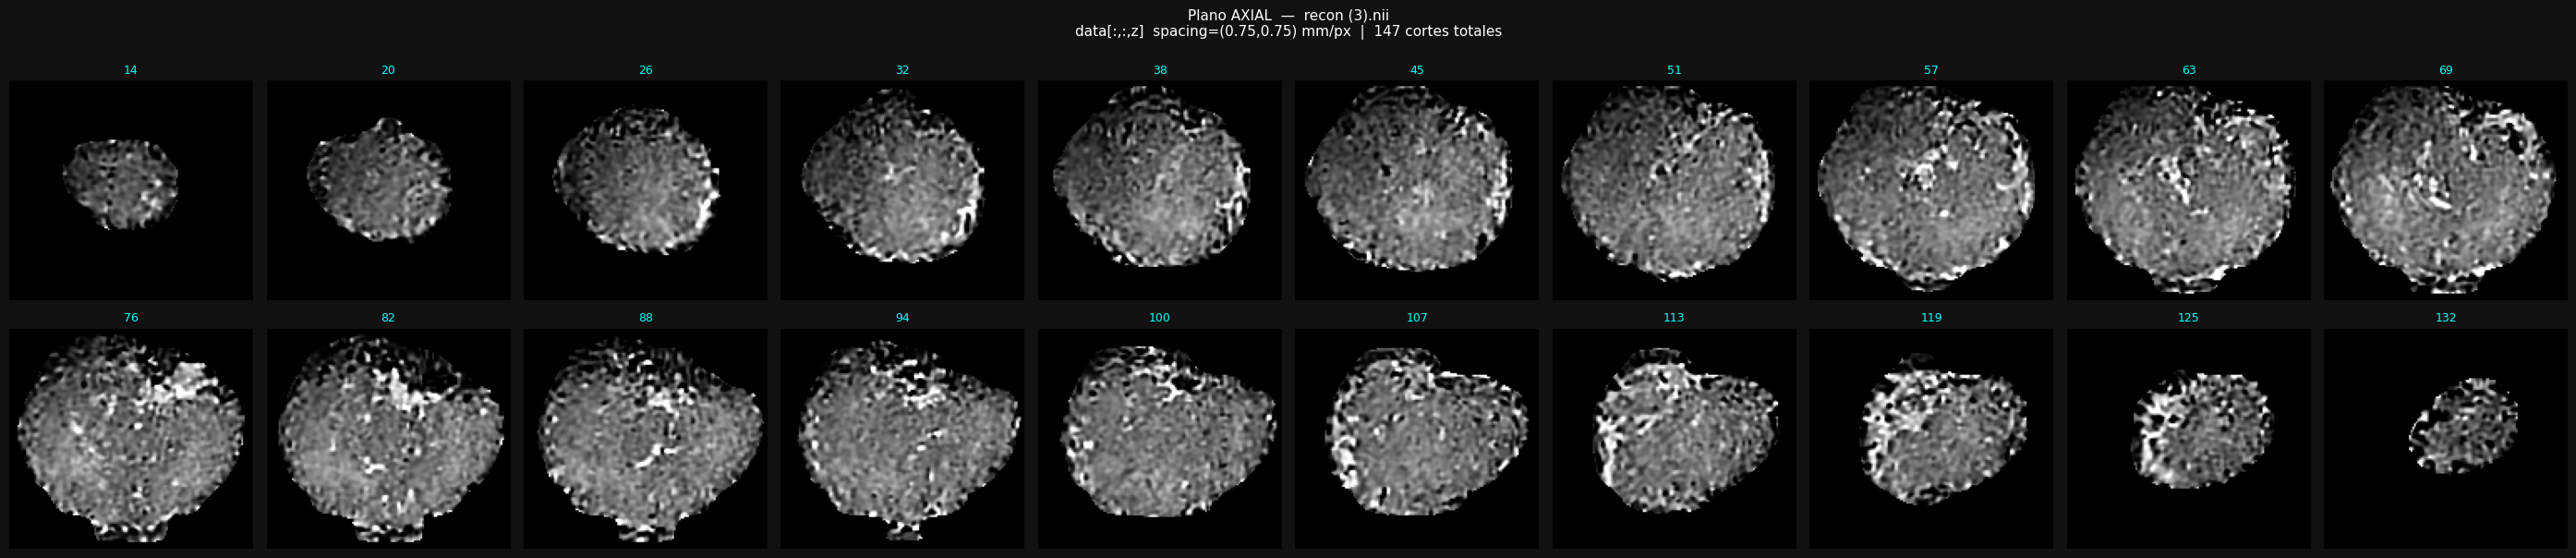

  AXIAL: indices → [14, 20, 26, 32, 38, 45, 51, 57, 63, 69, 76, 82, 88, 94, 100, 107, 113, 119, 125, 132]



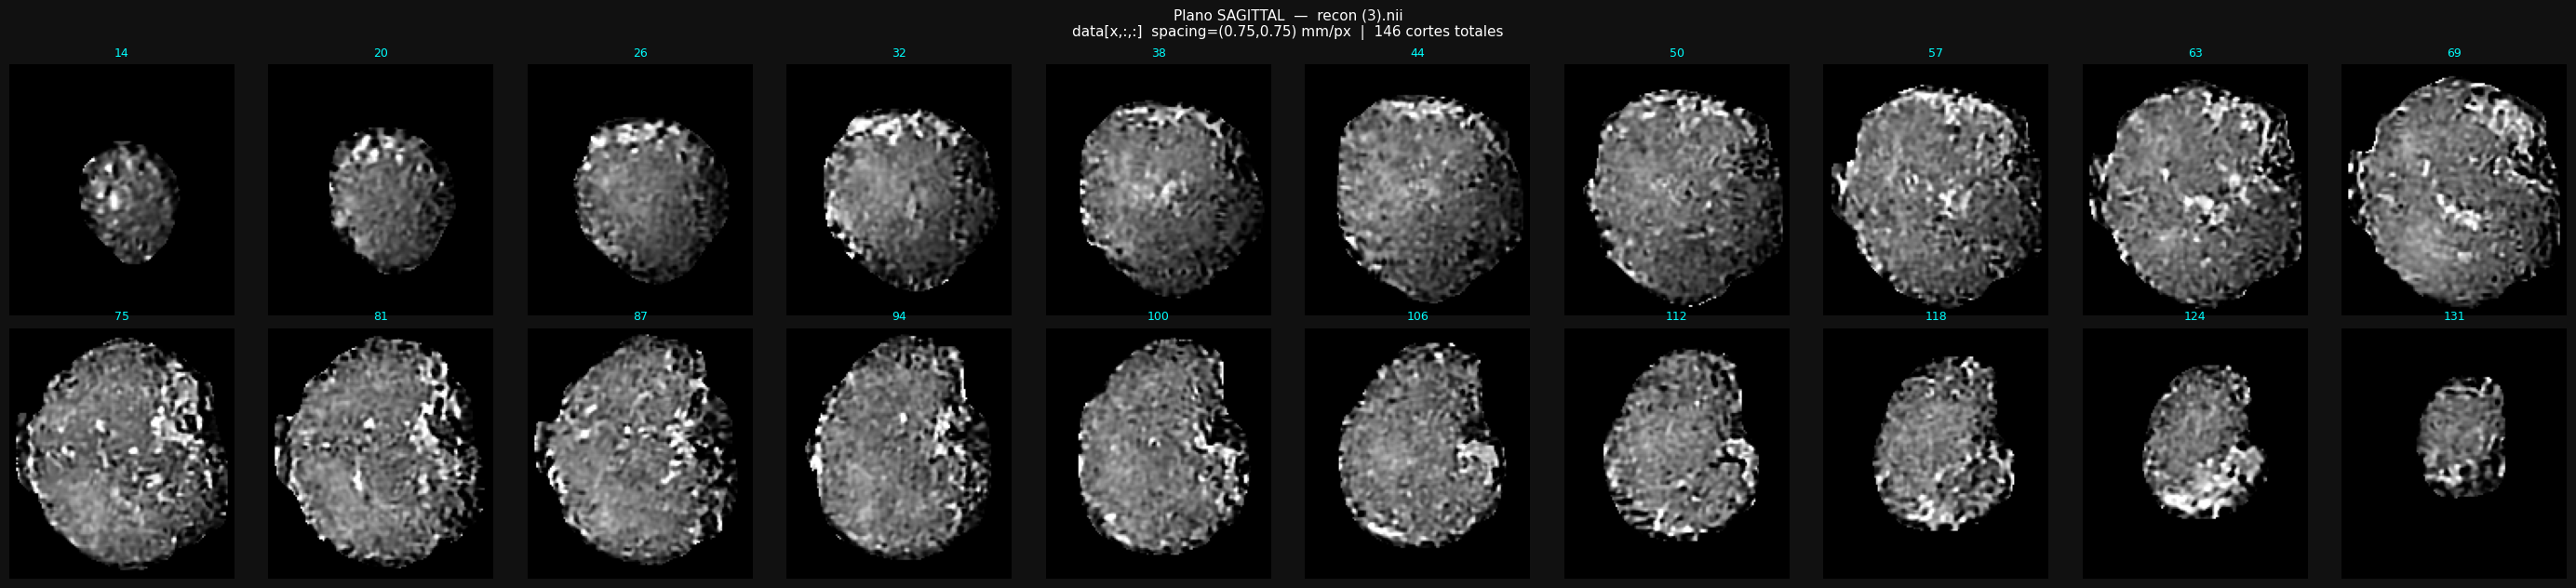

  SAGITTAL: indices → [14, 20, 26, 32, 38, 44, 50, 57, 63, 69, 75, 81, 87, 94, 100, 106, 112, 118, 124, 131]



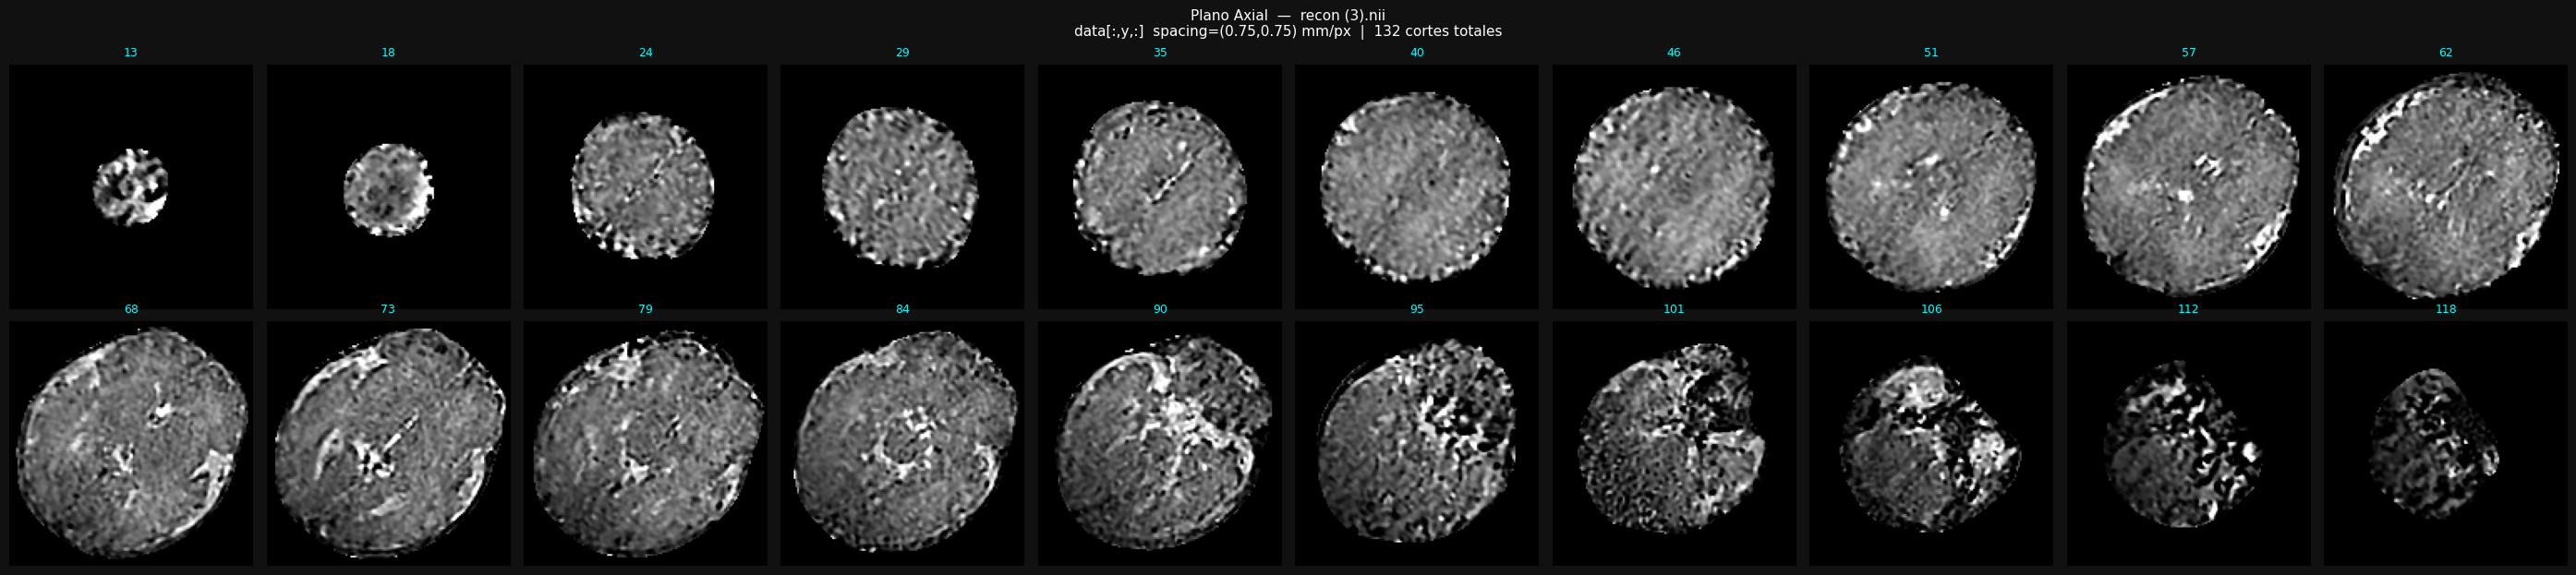

  Axial: indices → [13, 18, 24, 29, 35, 40, 46, 51, 57, 62, 68, 73, 79, 84, 90, 95, 101, 106, 112, 118]



In [8]:
# ==============================================================
# CELDA 3B — EXPLORADOR DE PLANOS (imagen mala calidad)
# Muestra 20 cortes de cada perspectiva para seleccion manual.
# ==============================================================

def show_plane_explorer(path, n_show=20):
    img  = nib.load(path)
    img  = nib.as_closest_canonical(img)
    data = img.get_fdata().squeeze().astype(np.float32)
    zooms = img.header.get_zooms()
    sx, sy, sz = float(zooms[0]), float(zooms[1]), float(zooms[2])
    nx, ny, nz = data.shape
    vmin = np.percentile(data, 0.5)
    vmax = np.percentile(data, 99.5)

    planes = [
        ('AXIAL',    nz, lambda i: data[:, :, i].T, f'data[:,:,z]  spacing=({sx:.2f},{sy:.2f}) mm/px'),
        ('SAGITTAL', nx, lambda i: data[i, :, :].T, f'data[x,:,:]  spacing=({sy:.2f},{sz:.2f}) mm/px'),
        ('Axial',  ny, lambda i: data[:, i, :].T, f'data[:,y,:]  spacing=({sx:.2f},{sz:.2f}) mm/px'),
    ]

    for plane_name, n_total, get_sl, sp_str in planes:
        idxs = [int(i) for i in np.linspace(
            int(n_total * 0.10), int(n_total * 0.90), n_show)]
        cols = 10
        rows = 2
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.8, rows * 3.2))
        fig.patch.set_facecolor('#111111')
        fig.suptitle(
            f'Plano {plane_name}  —  {Path(path).name}\n'
            f'{sp_str}  |  {n_total} cortes totales',
            fontsize=11, color='white'
        )
        for ax, si in zip(axes.flatten(), idxs):
            sl = get_sl(si)
            ax.imshow(sl, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
            ax.set_title(str(si), fontsize=9, color='cyan')
            ax.axis('off')
            ax.set_facecolor('#1a1a1a')
        plt.tight_layout()
        plt.show()
        print(f'  {plane_name}: indices → {idxs}')
        print()

show_plane_explorer(path_bad)

In [9]:
plane_bad = 'coronal'
slice_bad = 73
print(f'✅  Seleccionado: plano={plane_bad}, corte={slice_bad}')

✅  Seleccionado: plano=coronal, corte=73


In [10]:
# ==============================================================
# CELDA 4 — ESCÁNER DE METADATOS
# Busca edad gestacional / edad fetal en todos los campos NIfTI
# y archivos auxiliares. Relevante para la imagen de mala calidad
# que contiene metadatos del momento del estudio.
# ==============================================================

def scan_fetal_metadata(path, img):
    # Escanea todas las ubicaciones posibles de metadatos NIfTI
    # buscando informacion de edad gestacional / edad fetal.
    found = {}
    hdr = img.header

    # 1. Campo descrip — cadena libre 80 caracteres
    try:
        d = hdr['descrip'].tobytes().decode('utf-8', errors='ignore').strip('\x00 ')
        if d:
            found['descrip'] = d
    except Exception:
        pass

    # 2. Campo aux_file
    try:
        a = hdr['aux_file'].tobytes().decode('utf-8', errors='ignore').strip('\x00 ')
        if a:
            found['aux_file'] = a
    except Exception:
        pass

    # 3. Parametros de intencion (pueden codificar edad gestacional)
    try:
        p1 = float(hdr['intent_p1'])
        p2 = float(hdr['intent_p2'])
        p3 = float(hdr['intent_p3'])
        code_int = int(hdr['intent_code'])
        if any(v != 0 for v in [p1, p2, p3]):
            found['intent_params'] = {
                'code': code_int, 'p1': p1, 'p2': p2, 'p3': p3
            }
    except Exception:
        pass

    # 4. Extensiones NIfTI (JSON embebido, DICOM, texto libre)
    try:
        for i, ext in enumerate(img.header.extensions):
            raw = ext.get_content()
            if isinstance(raw, bytes):
                raw = raw.decode('utf-8', errors='ignore').strip('\x00 ')
            if raw:
                try:
                    found[f'extension_{i}'] = json.loads(raw)
                except Exception:
                    found[f'extension_{i}_text'] = raw[:500]
    except Exception:
        pass

    # 5. Sidecar JSON (formato BIDS)
    base = Path(path)
    for sfx in ('.nii.gz', '.nii'):
        if base.name.endswith(sfx):
            base = Path(str(base)[:-len(sfx)])
            break
    jp = base.with_suffix('.json')
    if jp.exists():
        with open(jp, encoding='utf-8', errors='ignore') as f:
            found['sidecar_json'] = json.load(f)

    # 6. Sidecar TXT
    tp = base.with_suffix('.txt')
    if tp.exists():
        found['sidecar_txt'] = tp.read_text(errors='ignore')[:1000]

    # 7. Escaneo de todos los campos del header buscando palabras clave
    age_kw = ['age', 'edad', 'week', 'semana', 'ga', 'gest', 'fetal']
    for field in hdr.keys():
        try:
            val_str = str(hdr[field])
            if any(k in field.lower() for k in age_kw) or \
               any(k in val_str.lower() for k in age_kw):
                found[f'hdr_{field}'] = val_str
        except Exception:
            pass

    return found


def print_metadata_report(path, img, quality_label):
    # Imprime reporte completo de metadatos para un volumen NIfTI.
    data  = img.get_fdata().squeeze()
    zooms = img.header.get_zooms()
    sx, sy, sz = float(zooms[0]), float(zooms[1]), float(zooms[2])
    sep = '=' * 60

    print(f'\n{sep}')
    print(f'  METADATOS — {quality_label}')
    print(f'  Archivo : {Path(path).name}')
    print(f'{sep}')
    print(f'  Shape        : {data.shape}')
    print(f'  Spacing      : {sx:.3f} x {sy:.3f} x {sz:.3f}  mm/px')
    print(f'  Orientacion  : {nib.aff2axcodes(img.affine)}')
    print(f'  Rango int.   : [{float(data.min()):.1f},  {float(data.max()):.1f}]')
    print(f'  Dtype        : {data.dtype}')

    meta = scan_fetal_metadata(path, img)

    if meta:
        print(f'\n  ── Metadatos adicionales encontrados ──')
        for k, v in meta.items():
            if isinstance(v, dict):
                print(f'  {k}:')
                for kk, vv in v.items():
                    print(f'      {kk}: {vv}')
            else:
                print(f'  {k}: {str(v)[:200]}')

        # Buscar indicio de edad gestacional
        all_text = json.dumps(meta, default=str).lower()
        found_age = False
        for kw in ['age', 'edad', 'week', 'semana', 'gestational', 'ga ']:
            if kw in all_text:
                if not found_age:
                    print(f'\n  ⚠️  Posible informacion de edad fetal detectada.')
                    print(f'     Revisar campos anteriores para valor exacto.')
                    found_age = True
    else:
        print(f'\n  (No se encontraron metadatos adicionales de edad fetal)')
    print()


print('✅  Funciones de metadatos definidas.')


✅  Funciones de metadatos definidas.


In [11]:
# ==============================================================
# CELDA 5 — FUNCIONES DSP DEL PROFESOR
# Ref: Tecnologico de Monterrey — Procesamiento de Imagenes Medicas
# ==============================================================

def filtro_2d(A, w):
    # Convolucion 2D con bucles explicitos (implementacion del profesor).
    A = np.array(A, dtype=float)
    w = np.array(w, dtype=float)
    N, M = A.shape
    nw = w.shape[0]
    Ap = np.zeros((N + nw - 1, M + nw - 1))
    Ap[1:N+1, 1:M+1] = A
    B = np.zeros((N, M))
    for n in range(N):
        for m in range(M):
            for i in range(-1, 2):
                for j in range(-1, 2):
                    B[n, m] += w[i+1, j+1] * Ap[n-i+1, m-j+1]
    return B


def filtro_pro(A, n):
    # Banco de filtros del profesor:
    # 1=Promedio, 2=Gaussiano, 3=dX, 4=dY,
    # 5=SobelX, 6=SobelY, 7=Laplaciano4, 8=Laplaciano8
    kernels = {
        1: np.ones((3, 3)) / 9,
        2: np.array([[0.36, 0.6, 0.36],
                     [0.6,  1.0, 0.6 ],
                     [0.36, 0.6, 0.36]]) / 4.8976,
        3: np.array([[ 1, 0, -1],
                     [ 1, 0, -1],
                     [ 1, 0, -1]], dtype=float),
        4: np.array([[-1, -1, -1],
                     [ 0,  0,  0],
                     [ 1,  1,  1]], dtype=float),
        5: np.array([[ 1, 0, -1],
                     [ 2, 0, -2],
                     [ 1, 0, -1]], dtype=float),
        6: np.array([[ 1,  2,  1],
                     [ 0,  0,  0],
                     [-1, -2, -1]], dtype=float),
        7: np.array([[ 0,  1,  0],
                     [ 1, -4,  1],
                     [ 0,  1,  0]], dtype=float),
        8: np.array([[ 1,  1,  1],
                     [ 1, -8,  1],
                     [ 1,  1,  1]], dtype=float),
    }
    return filtro_2d(A, kernels[n])


def anisotropic_diffusion(img, niter=8, kappa=30, gamma=0.1):
    # Difusion anisotropa Perona-Malik (1990).
    # Preserva bordes ventriculares mientras suaviza ruido interno.
    # Se aplica ANTES del preprocesamiento — especialmente util
    # en imagenes de mala calidad con bajo SNR.
    #
    # niter  : iteraciones de difusion
    # kappa  : conductancia (menor = preserva mas bordes)
    # gamma  : paso de tiempo (debe ser <= 0.25)
    img = img.astype(np.float64)
    for _ in range(niter):
        dN = np.roll(img, -1, axis=0) - img
        dS = np.roll(img,  1, axis=0) - img
        dE = np.roll(img, -1, axis=1) - img
        dW = np.roll(img,  1, axis=1) - img
        cN = np.exp(-(dN / kappa) ** 2)
        cS = np.exp(-(dS / kappa) ** 2)
        cE = np.exp(-(dE / kappa) ** 2)
        cW = np.exp(-(dW / kappa) ** 2)
        img += gamma * (cN*dN + cS*dS + cE*dE + cW*dW)
    return img.astype(np.float32)


def construir_overlay(corte, mask):
    # Superpone mascara en rojo sobre imagen en escala de grises.
    ov = np.stack([corte / max(float(corte.max()), 1e-8)] * 3, axis=-1)
    ov[:, :, 0] = np.where(mask == 1, 1.0, ov[:, :, 0])
    ov[:, :, 1] = np.where(mask == 1, 0.2, ov[:, :, 1])
    ov[:, :, 2] = np.where(mask == 1, 0.2, ov[:, :, 2])
    return ov


print('✅  Funciones DSP del profesor cargadas.')


✅  Funciones DSP del profesor cargadas.


In [12]:
# ==============================================================
# CELDA 6 — FUNCIONES PIPELINE (Axial v3 + region growing)
# ==============================================================

def normalize_percentile(vol, plow=0.5, phigh=99.5):
    vmin = np.percentile(vol, plow)
    vmax = np.percentile(vol, phigh)
    return (np.clip(vol, vmin, vmax) - vmin) / (vmax - vmin + 1e-8)


def get_brain_roi_axial(vol_norm, threshold=0.05, margin=0.05):
    proj   = vol_norm.max(axis=2)
    brain  = proj > threshold
    coords = np.where(brain)
    if len(coords[0]) == 0:
        return 0, vol_norm.shape[0], 0, vol_norm.shape[1]
    x0, x1 = coords[0].min(), coords[0].max()
    y0, y1 = coords[1].min(), coords[1].max()
    dx = int((x1 - x0) * margin)
    dy = int((y1 - y0) * margin)
    return (max(0, x0 - dx), min(vol_norm.shape[0], x1 + dx),
            max(0, y0 - dy), min(vol_norm.shape[1], y1 + dy))


def get_roi_from_slice(slice_2d, threshold=0.05, margin=0.05):
    norm   = normalize_percentile(slice_2d)
    brain  = norm > threshold
    coords = np.where(brain)
    if len(coords[0]) == 0:
        return 0, slice_2d.shape[0], 0, slice_2d.shape[1]
    r0, r1 = coords[0].min(), coords[0].max()
    c0, c1 = coords[1].min(), coords[1].max()
    dr = int((r1 - r0) * margin)
    dc = int((c1 - c0) * margin)
    return (max(0, r0 - dr), min(slice_2d.shape[0], r1 + dr),
            max(0, c0 - dc), min(slice_2d.shape[1], c1 + dc))


def compute_snr(slice_2d):
    fg = slice_2d[slice_2d > 0.05]
    return float(fg.mean() / (fg.std() + 1e-8)) if len(fg) > 10 else 0.0


def preprocess_slice(slice_2d, cfg):
    snr    = compute_snr(slice_2d)
    sigma  = cfg['sigma_normal'] if snr >= cfg['snr_thresh'] else cfg['sigma_lowsnr']
    img_u8 = (np.clip(slice_2d, 0, 1) * 255).astype(np.uint8)
    den    = cv2.medianBlur(img_u8, cfg['median_ksize']).astype(np.float64) / 255.0
    clahe  = exposure.equalize_adapthist(den,
                                          clip_limit=cfg['clahe_clip'],
                                          nbins=cfg['clahe_nbins'])
    gauss  = gaussian_filter(clahe, sigma=sigma)
    g_u8   = (gauss * 255).astype(np.uint8)
    bil    = cv2.bilateralFilter(g_u8,
                                  d=cfg['bilateral_d'],
                                  sigmaColor=cfg['bilateral_sc'],
                                  sigmaSpace=cfg['bilateral_ss'])
    return bil.astype(np.float64) / 255.0, snr, sigma


def detect_midline(slice_proc, brain_mask_2d):
    brain_coords = np.where(brain_mask_2d)
    if len(brain_coords[0]) == 0:
        mid = slice_proc.shape[0] // 2
        return mid, None, None, mid - 5, mid + 5, mid, mid
    brain_cols = brain_coords[0]
    brain_rows = brain_coords[1]
    centroid_x = int(brain_cols.mean())
    col_min, col_max = brain_cols.min(), brain_cols.max()
    row_min, row_max = brain_rows.min(), brain_rows.max()
    brain_width  = col_max - col_min
    brain_height = row_max - row_min
    margin  = int(brain_width * 0.12)
    s_start = max(0, centroid_x - margin)
    s_end   = min(slice_proc.shape[0], centroid_x + margin)
    n_cols  = slice_proc.shape[0]
    col_profile = np.zeros(n_cols)
    for c in range(n_cols):
        px = slice_proc[c, :][brain_mask_2d[c, :]]
        col_profile[c] = px.mean() if len(px) > 5 else 1.0
    col_smooth = gaussian_filter(col_profile, sigma=2)

    def notch_in_strip(r0, r1):
        strip = slice_proc[s_start:s_end, r0:r1]
        if strip.size == 0:
            return centroid_x
        return int(np.argmin(strip.mean(axis=1))) + s_start

    front_h     = int(brain_height * 0.15)
    back_h      = int(brain_height * 0.15)
    notch_front = notch_in_strip(row_max - front_h, row_max)
    notch_back  = notch_in_strip(row_min, row_min + back_h)
    midline_col = int((centroid_x * 1 + notch_front * 2 + notch_back * 2) / 5)
    return midline_col, col_profile, col_smooth, s_start, s_end, notch_front, notch_back


def fill_ventricle_from_seed(seed_mask, slice_proc, brain_mask, cfg):
    if seed_mask.sum() == 0:
        return seed_mask
    filled   = binary_fill_holes(seed_mask)
    brain_px = slice_proc[brain_mask]
    if len(brain_px) < 50:
        return filled
    prev_sum = filled.sum()
    for step in [5, 10, 15, 20, 25, 30]:
        pct = cfg['ventricle_pct'] - step
        if pct < 45:
            break
        t_pct     = np.percentile(brain_px, pct)
        candidate = (slice_proc > t_pct) & brain_mask
        labeled_c, n_lab = scipy_label(candidate)
        new_mask = np.zeros_like(filled, dtype=bool)
        for lbl in range(1, n_lab + 1):
            comp = (labeled_c == lbl)
            if (comp & filled).any():
                new_mask |= comp
        if new_mask.sum() == 0 or new_mask.sum() > prev_sum * 8:
            break
        filled   = binary_fill_holes(new_mask)
        prev_sum = filled.sum()
    filled = binary_closing(filled, disk(cfg['close_r']))
    filled = remove_small_objects(filled, min_size=cfg['min_size'])
    return filled


def segment_ventricles(slice_proc, brain_mask_2d, midline_col, cfg):
    brain_area     = brain_mask_2d.sum()
    brain_rows_idx = np.where(brain_mask_2d.any(axis=0))[0]
    brain_cols_idx = np.where(brain_mask_2d.any(axis=1))[0]
    if len(brain_rows_idx) == 0 or len(brain_cols_idx) == 0:
        return np.zeros_like(brain_mask_2d), np.zeros_like(brain_mask_2d)
    row_min, row_max = brain_rows_idx.min(), brain_rows_idx.max()
    col_min, col_max = brain_cols_idx.min(), brain_cols_idx.max()
    brain_h = row_max - row_min
    brain_w = col_max - col_min
    mp = 0.20
    inner_col_min = col_min + int(brain_w * mp)
    inner_col_max = col_max - int(brain_w * mp)
    inner_row_min = row_min + int(brain_h * mp)
    inner_row_max = row_max - int(brain_h * mp)

    def find_ventricle_in_hemi(hemi_sl, hemi_mask, mid_col):
        brain_px = hemi_sl[hemi_mask]
        if len(brain_px) < 50:
            return np.zeros_like(hemi_mask)
        thresh  = np.percentile(brain_px, cfg['ventricle_pct'])
        binary  = (hemi_sl > thresh) & hemi_mask
        binary  = binary_closing(binary, disk(cfg['close_r']))
        binary  = binary_opening(binary, disk(cfg['open_r']))
        binary  = remove_small_objects(binary, min_size=cfg['min_size'])
        labeled, n_lab = scipy_label(binary)
        if n_lab == 0:
            return binary
        hemi_c = np.where(hemi_mask.any(axis=1))[0]
        if len(hemi_c) == 0:
            return np.zeros_like(binary)
        hemi_w   = hemi_c.max() - hemi_c.min()
        max_dist = hemi_w * 0.55
        valid = []
        for i in range(1, n_lab + 1):
            comp = (labeled == i)
            size = comp.sum()
            if size > brain_area * cfg['max_ventricle_pct']:
                continue
            cx = int(np.where(comp)[0].mean())
            cy = int(np.where(comp)[1].mean())
            if abs(cx - mid_col) > max_dist:
                continue
            if not (inner_col_min <= cx <= inner_col_max and
                    inner_row_min <= cy <= inner_row_max):
                continue
            valid.append((size, comp))
        if not valid:
            return np.zeros_like(binary)
        valid.sort(key=lambda x: x[0], reverse=True)
        seed = valid[0][1]
        return fill_ventricle_from_seed(seed, hemi_sl, hemi_mask, cfg)

    left_sl  = slice_proc.copy(); left_sl[midline_col:, :]   = 0
    right_sl = slice_proc.copy(); right_sl[:midline_col, :]  = 0
    left_m   = brain_mask_2d.copy(); left_m[midline_col:, :] = False
    right_m  = brain_mask_2d.copy(); right_m[:midline_col,:] = False
    return (find_ventricle_in_hemi(left_sl,  left_m,  midline_col),
            find_ventricle_in_hemi(right_sl, right_m, midline_col))


def segment_sagittal_ventricle(slice_proc, brain_mask, cfg):
    if brain_mask.sum() == 0:
        return np.zeros_like(brain_mask, dtype=bool)
    brain_px = slice_proc[brain_mask]
    if len(brain_px) < 50:
        return np.zeros_like(brain_mask, dtype=bool)
    brain_coords = np.where(brain_mask)
    rmin, rmax = brain_coords[0].min(), brain_coords[0].max()
    cmin, cmax = brain_coords[1].min(), brain_coords[1].max()
    rh = rmax - rmin
    cw = cmax - cmin
    margin = 0.12
    inner = np.zeros_like(brain_mask, dtype=bool)
    inner[rmin+int(rh*margin):rmax-int(rh*margin),
          cmin+int(cw*margin):cmax-int(cw*margin)] = True
    inner &= brain_mask
    t_seed = np.percentile(brain_px, cfg['ventricle_pct'])
    seed   = (slice_proc > t_seed) & inner
    seed   = binary_closing(seed, disk(cfg['close_r']))
    seed   = remove_small_objects(seed, min_size=cfg['min_size'])
    if seed.sum() == 0:
        return seed
    labeled_s, n_lab = scipy_label(seed)
    if n_lab > 1:
        sizes = [(labeled_s == i).sum() for i in range(1, n_lab + 1)]
        seed  = (labeled_s == int(np.argmax(sizes)) + 1)
    return fill_ventricle_from_seed(seed, slice_proc, inner, cfg)


def min_bounding_rect_width(binary_mask, spacing_x, spacing_y):
    img_u8      = binary_mask.astype(np.uint8) * 255
    contours, _ = cv2.findContours(img_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0.0, None
    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < 10:
        return 0.0, None
    rect       = cv2.minAreaRect(largest)
    w_px, h_px = rect[1]
    short_side = min(w_px, h_px)
    return float(short_side * np.mean([spacing_x, spacing_y])), rect


def diagnose(width_mm, cfg):
    if   width_mm < cfg['mild_mm']:     return 'Normal',      'limegreen'
    elif width_mm < cfg['moderate_mm']: return 'VM Leve',     'gold'
    elif width_mm < cfg['severe_mm']:   return 'VM Moderada', 'orange'
    else:                               return 'VM Severa',   'red'


def draw_rect_on_ax(ax, rect, color, label):
    if rect is None:
        return
    box  = cv2.boxPoints(rect).astype(int)
    poly = plt.Polygon(box[:, ::-1], fill=False, edgecolor=color, lw=1.5, label=label)
    ax.add_patch(poly)


def digital_analysis_metrics(slice_raw, sx, sy):
    rows, cols = slice_raw.shape
    raw_max    = float(slice_raw.max())
    res_bits   = math.ceil(math.log2(max(raw_max + 1, 2)))
    fg         = slice_raw[slice_raw > slice_raw.mean() * 0.1]
    snr_v      = float(fg.mean() / (fg.std() + 1e-8)) if len(fg) > 10 else 0.0
    return {
        'Matriz'              : f'{rows} x {cols} px',
        'Resolucion espacial' : f'{sx:.3f} x {sy:.3f}  mm/px',
        'Bits intensidad'     : f'{res_bits}  bits',
        'FOV x'               : f'{rows * sx:.1f}  mm',
        'FOV y'               : f'{cols * sy:.1f}  mm',
        'Freq. Nyquist x'     : f'{1/(2*sx):.3f}  c/mm',
        'Freq. Nyquist y'     : f'{1/(2*sy):.3f}  c/mm',
        'Media intensidad'    : f'{float(slice_raw.mean()):.2f}',
        'Std intensidad'      : f'{float(slice_raw.std()):.2f}',
        'SNR estimado'        : f'{snr_v:.2f}',
        'Min / Max'           : f'{float(slice_raw.min()):.1f} / {raw_max:.1f}',
    }


print('✅  Funciones pipeline cargadas (incluyendo get_roi_from_slice, segment_sagittal_ventricle).')

✅  Funciones pipeline cargadas (incluyendo get_roi_from_slice, segment_sagittal_ventricle).


In [13]:
# ==============================================================
# CELDA 7 — FUNCIONES DE VISUALIZACION
# ==============================================================

def _plot_score_and_raw(quality_label, fname, data_norm,
                        x0, x1, y0, y1, z_best, z_range,
                        scores_raw, scores_sm, slice_raw, snr_val):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.patch.set_facecolor('#111111')
    for ax in axes:
        ax.set_facecolor('#1a1a1a')

    axes[0].fill_between(z_range, scores_raw, alpha=0.2, color='steelblue')
    axes[0].plot(z_range, scores_raw, color='steelblue', lw=1, alpha=0.6, label='Score raw')
    axes[0].plot(z_range, scores_sm,  color='tomato',    lw=2.5,           label='Suavizado')
    axes[0].axvline(z_best, color='limegreen', ls='--', lw=2, label=f'z={z_best} (optimo)')
    axes[0].set_xlabel('Corte Z (axial)', color='white')
    axes[0].set_ylabel('Score CSF',       color='white')
    axes[0].set_title('Score ventricular por corte axial', color='white')
    axes[0].tick_params(colors='white')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.25)

    z_mid = data_norm.shape[2] // 2
    axes[1].imshow(data_norm[x0:x1, y0:y1, z_mid].T, cmap='gray', origin='lower')
    axes[1].set_title(f'Corte central (z={z_mid})', color='white', fontsize=9)
    axes[1].axis('off')

    axes[2].imshow(slice_raw.T, cmap='gray', origin='lower')
    axes[2].set_title(f'Corte seleccionado z={z_best}\nSNR={snr_val:.2f}',
                      color='white', fontsize=9)
    axes[2].axis('off')

    plt.suptitle(f'{fname}  [{quality_label}]  —  Seleccion de Corte Axial',
                 fontsize=11, color='white')
    plt.tight_layout()
    plt.show()


def _plot_pipeline_steps(quality_label, fname,
                          slice_raw, slice_aniso, slice_proc, brain_mask,
                          midline_col, notch_front, notch_back,
                          left_v, right_v, rect_L, rect_R,
                          width_L, width_R, final_diameter,
                          classification, class_color, sigma_used, cfg):
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    fig.patch.set_facecolor('#111111')
    fig.suptitle(f'{fname}  [{quality_label}]  —  {classification}  ({final_diameter:.2f} mm)',
                 fontsize=13, fontweight='bold', color=class_color)

    kw = dict(origin='lower')

    axes[0,0].imshow(slice_raw.T,   cmap='gray', **kw)
    axes[0,0].set_title('1. Corte axial (raw)', fontsize=9, color='white')

    axes[0,1].imshow(slice_aniso.T, cmap='gray', **kw)
    axes[0,1].set_title(f'2. Difusion anisotropa\nniter={cfg["aniso_niter"]}, kappa={cfg["aniso_kappa"]}',
                         fontsize=9, color='white')

    axes[0,2].imshow(slice_proc.T,  cmap='gray', **kw)
    axes[0,2].set_title(f'3. Post-proceso  sigma={sigma_used}', fontsize=9, color='white')

    axes[0,3].imshow(slice_proc.T,  cmap='gray',   **kw)
    axes[0,3].imshow(brain_mask.T.astype(float), cmap='Greens', alpha=0.35, **kw)
    axes[0,3].set_title('4. Mascara cerebral (Otsu)', fontsize=9, color='white')

    axes[1,0].imshow(slice_proc.T, cmap='gray', **kw)
    axes[1,0].axvline(midline_col, color='cyan',   lw=2,   ls='--', label=f'Cisura={midline_col}')
    axes[1,0].axvline(notch_front, color='lime',   lw=1.2, ls=':',  label=f'Frontal={notch_front}')
    axes[1,0].axvline(notch_back,  color='yellow', lw=1.2, ls=':',  label=f'Trasera={notch_back}')
    axes[1,0].set_title('5. Cisura interhemisferica', fontsize=9, color='white')
    axes[1,0].legend(fontsize=6, loc='lower right')

    axes[1,1].imshow(slice_proc.T, cmap='gray',  **kw)
    axes[1,1].imshow(left_v.T,     cmap='Blues', alpha=0.65, **kw)
    axes[1,1].set_title(f'6. Ventriculo izquierdo\n{width_L:.2f} mm',
                         fontsize=9, color='deepskyblue')

    axes[1,2].imshow(slice_proc.T, cmap='gray', **kw)
    axes[1,2].imshow(right_v.T,    cmap='Reds', alpha=0.65, **kw)
    axes[1,2].set_title(f'7. Ventriculo derecho\n{width_R:.2f} mm',
                         fontsize=9, color='tomato')

    axes[1,3].imshow(slice_proc.T, cmap='gray',  **kw)
    axes[1,3].imshow(left_v.T,     cmap='Blues', alpha=0.45, **kw)
    axes[1,3].imshow(right_v.T,    cmap='Reds',  alpha=0.45, **kw)
    axes[1,3].axvline(midline_col, color='cyan', lw=1.5, ls='--')
    draw_rect_on_ax(axes[1,3], rect_L, 'deepskyblue', f'L={width_L:.1f}mm')
    draw_rect_on_ax(axes[1,3], rect_R, 'tomato',      f'R={width_R:.1f}mm')
    axes[1,3].set_title(f'8. Medicion (minAreaRect)\nL={width_L:.1f}  R={width_R:.1f} mm',
                         fontsize=9, color='white')
    axes[1,3].legend(fontsize=7)

    for row in axes:
        for ax in row:
            ax.axis('off')
            ax.set_facecolor('#1a1a1a')
    plt.tight_layout()
    plt.show()


def _plot_multiplanar(quality_label, fname, widths_mp,
                       final_diameter, cv, n_cross, cfg):
    if not widths_mp:
        print('   (Sin cortes multiplanares adicionales validos)')
        return
    fig, ax = plt.subplots(figsize=(11, 3.5))
    fig.patch.set_facecolor('#111111')
    ax.set_facecolor('#1a1a1a')
    bar_colors = ['limegreen' if w < cfg['mild_mm']
                  else 'gold'   if w < cfg['moderate_mm']
                  else 'orange' if w < cfg['severe_mm']
                  else 'red'    for w in widths_mp]
    ax.bar(range(len(widths_mp)), widths_mp, color=bar_colors, edgecolor='white', lw=0.5)
    ax.axhline(final_diameter,         color='white',  lw=2,   ls='--',
               label=f'Media={final_diameter:.1f} mm')
    ax.axhline(cfg['mild_mm'],     color='gold',   lw=1.2, ls=':', label='10 mm (Leve)')
    ax.axhline(cfg['moderate_mm'], color='orange', lw=1.2, ls=':', label='12 mm (Moderada)')
    ax.axhline(cfg['severe_mm'],   color='red',    lw=1.2, ls=':', label='15 mm (Severa)')
    ax.set_title(f'{fname}  [{quality_label}]  —  '
                 f'Validacion Multiplanar +-{n_cross} cortes  |  CV={cv*100:.1f}%',
                 fontsize=10, color='white')
    ax.set_ylabel('Diametro (mm)', color='white')
    ax.set_xlabel('Indice de corte evaluado', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


print('✅  Funciones de visualizacion definidas.')


✅  Funciones de visualizacion definidas.


In [14]:
# ==============================================================
# CELDA 8 — FUNCION PRINCIPAL run_full_pipeline (v2)
# Fixes: brain mask usa slice_raw (no slice_proc)
# Nuevo:  plane_override / slice_idx_override para modo manual
# ==============================================================

def get_roi_from_slice(slice_2d, threshold=0.05, margin=0.05):
    norm   = normalize_percentile(slice_2d)
    brain  = norm > threshold
    coords = np.where(brain)
    if len(coords[0]) == 0:
        return 0, slice_2d.shape[0], 0, slice_2d.shape[1]
    r0, r1 = coords[0].min(), coords[0].max()
    c0, c1 = coords[1].min(), coords[1].max()
    dr = int((r1 - r0) * margin)
    dc = int((c1 - c0) * margin)
    return (max(0, r0 - dr), min(slice_2d.shape[0], r1 + dr),
            max(0, c0 - dc), min(slice_2d.shape[1], c1 + dc))


def run_full_pipeline(path, quality_label, cfg,
                      plane_override=None, slice_idx_override=None):

    sep = '=' * 62
    print(f'\n{sep}')
    print(f'  ANALIZANDO : {Path(path).name}')
    print(f'  Calidad    : {quality_label}')
    if plane_override:
        print(f'  Modo       : MANUAL  plano={plane_override}  corte={slice_idx_override}')
    print(f'{sep}')

    # ── 1. CARGA ────────────────────────────────────────────────
    img      = nib.load(path)
    img      = nib.as_closest_canonical(img)
    data_raw = img.get_fdata().squeeze().astype(np.float32)
    zooms    = img.header.get_zooms()
    sx, sy, sz = float(zooms[0]), float(zooms[1]), float(zooms[2])
    print(f'   Shape      : {data_raw.shape}')
    print(f'   Spacing    : {sx:.3f} x {sy:.3f} x {sz:.3f}  mm/px')
    print(f'   Orientacion: {nib.aff2axcodes(img.affine)}')

    # ── 2. NORMALIZACION ─────────────────────────────────────────
    data_norm = normalize_percentile(data_raw, cfg['pct_low'], cfg['pct_high'])

    # ── 3. SELECCION DE PLANO Y CORTE ────────────────────────────
    if plane_override is not None:
        # Modo manual: plano y corte elegido por el usuario
        plane = plane_override
        if plane == 'axial':
            slice_raw_full = data_norm[:, :, slice_idx_override]
            sp_x, sp_y = sx, sy
            use_hemi = True
        elif plane == 'sagittal':
            slice_raw_full = data_norm[slice_idx_override, :, :]
            sp_x, sp_y = sy, sz
            use_hemi = False
        elif plane == 'coronal':
            slice_raw_full = data_norm[:, slice_idx_override, :]
            sp_x, sp_y = sx, sz    # ← coronal: eje x (R) y eje z (S)
            use_hemi = True
        r0, r1, c0, c1 = get_roi_from_slice(slice_raw_full,
                                              cfg['brain_thresh'],
                                              cfg['roi_margin'])
        slice_raw = slice_raw_full[r0:r1, c0:c1].copy()
        z_best    = slice_idx_override
        scores_raw, scores_sm, z_range = None, None, None
        print(f'   Plano      : {plane}  corte={z_best}')
        print(f'   ROI        : r=[{r0}:{r1}]  c=[{c0}:{c1}]')
    else:
        # Modo automatico: axial con score CSF
        plane    = 'axial'
        use_hemi = True
        sp_x, sp_y = sx, sy
        x0, x1, y0, y1 = get_brain_roi_axial(data_norm,
                                               cfg['brain_thresh'],
                                               cfg['roi_margin'])
        print(f'   ROI        : x=[{x0}:{x1}]  y=[{y0}:{y1}]')
        n_z     = data_norm.shape[2]
        z_min   = int(n_z * cfg['z_range_pct'][0])
        z_max   = int(n_z * cfg['z_range_pct'][1])
        z_range = list(range(z_min, z_max))
        roi_vol = data_norm[x0:x1, y0:y1, :]
        tl = np.percentile(roi_vol, cfg['csf_pct_low'])
        th = np.percentile(roi_vol, cfg['csf_pct_high'])
        scores_raw = np.array([
            int(np.sum((data_norm[x0:x1, y0:y1, z] >= tl) &
                       (data_norm[x0:x1, y0:y1, z] <= th)))
            for z in z_range], dtype=float)
        scores_sm = gaussian_filter(scores_raw, sigma=cfg['score_sigma'])
        z_best    = z_range[int(np.argmax(scores_sm))]
        slice_raw = data_norm[x0:x1, y0:y1, z_best].copy()
        r0, c0    = x0, y0   # keep for raw metrics
        r1, c1    = x1, y1
        print(f'   Corte z    : {z_best}  (score CSF max={scores_sm.max():.1f})')

    # ── 4. DIFUSION ANISOTROPA ───────────────────────────────────
    slice_aniso = anisotropic_diffusion(slice_raw,
                                         niter=cfg['aniso_niter'],
                                         kappa=cfg['aniso_kappa'],
                                         gamma=cfg['aniso_gamma'])

    # ── 5. PREPROCESAMIENTO (Median->CLAHE->Gauss->Bilateral) ────
    slice_proc, snr_val, sigma_used = preprocess_slice(slice_aniso, cfg)
    snr_label = 'Normal' if snr_val >= cfg['snr_thresh'] else 'Low-SNR'
    print(f'   SNR        : {snr_val:.2f}  sigma={sigma_used}  ({snr_label})')

    # ── 6. MASCARA CEREBRAL ──────────────────────────────────────
    # FIX: usar slice_raw (antes de CLAHE) para Otsu — CLAHE infla
    # el background y hace que Otsu elija un umbral demasiado bajo.
    thresh_b   = threshold_otsu(slice_raw)
    brain_mask = binary_fill_holes(
        remove_small_objects(slice_raw > thresh_b, min_size=100))

    # ── 7. CISURA + SEGMENTACION ─────────────────────────────────
    if use_hemi:
        midline_col, col_profile, col_smooth, s_start, s_end, \
            notch_front, notch_back = detect_midline(slice_proc, brain_mask)
        left_v, right_v = segment_ventricles(slice_proc, brain_mask,
                                              midline_col, cfg)
        print(f'   Cisura     : col={midline_col}')
    else:
        # Sagital: sin division hemisferica
        midline_col = slice_proc.shape[0] // 2
        notch_front = midline_col; notch_back = midline_col
        ventricle   = segment_sagittal_ventricle(slice_proc, brain_mask, cfg)
        # Dividir resultado en dos mitades para mantener interfaz uniforme
        left_v  = np.zeros_like(brain_mask, dtype=bool)
        right_v = np.zeros_like(brain_mask, dtype=bool)
        half = slice_proc.shape[0] // 2
        left_v[:half,  :] = ventricle[:half,  :]
        right_v[half:, :] = ventricle[half:, :]

    lv_px = left_v.sum(); rv_px = right_v.sum()
    print(f'   Vent. izq  : {"OK" if lv_px > 0 else "no detectado"}  ({lv_px} px)')
    print(f'   Vent. der  : {"OK" if rv_px > 0 else "no detectado"}  ({rv_px} px)')

    # ── 8. MEDICION ──────────────────────────────────────────────
    width_L, rect_L = min_bounding_rect_width(left_v,  sp_x, sp_y)
    width_R, rect_R = min_bounding_rect_width(right_v, sp_x, sp_y)
    # Para sagital: usar la mascara completa si ambas mitades son pequeñas
    if not use_hemi and width_L == 0 and width_R == 0:
        ventricle_full = left_v | right_v
        width_L, rect_L = min_bounding_rect_width(ventricle_full, sp_x, sp_y)
        width_R, rect_R = 0.0, None
    width_single  = max(width_L, width_R)
    dominant_side = 'Izquierdo' if width_L >= width_R else 'Derecho'
    print(f'   Ancho L={width_L:.2f} mm   R={width_R:.2f} mm')

    # ── 9. VALIDACION MULTIPLANAR ─────────────────────────────────
    n_cross   = cfg['cross_slices']
    widths_mp = []
    for dz in range(-n_cross, n_cross + 1):
        if plane == 'axial':
            zc = z_best + dz
            if not (0 <= zc < data_norm.shape[2]): continue
            sl_c = data_norm[r0:r1, c0:c1, zc].copy()
        elif plane == 'sagittal':
            zc = z_best + dz
            if not (0 <= zc < data_norm.shape[0]): continue
            sl_full = data_norm[zc, :, :]
            rr0,rr1,cc0,cc1 = get_roi_from_slice(sl_full, cfg['brain_thresh'], cfg['roi_margin'])
            sl_c = sl_full[rr0:rr1, cc0:cc1].copy()
        elif plane == 'coronal':
            zc = z_best + dz
            if not (0 <= zc < data_norm.shape[1]): continue
            sl_full = data_norm[:, zc, :]
            rr0,rr1,cc0,cc1 = get_roi_from_slice(sl_full, cfg['brain_thresh'], cfg['roi_margin'])
            sl_c = sl_full[rr0:rr1, cc0:cc1].copy()

        sl_a = anisotropic_diffusion(sl_c, niter=cfg['aniso_niter'],
                                      kappa=cfg['aniso_kappa'], gamma=cfg['aniso_gamma'])
        sp_c, _, _ = preprocess_slice(sl_a, cfg)
        # FIX mascara: usar sl_c (raw) no sp_c
        bm_c = binary_fill_holes(
            remove_small_objects(sl_c > threshold_otsu(sl_c), min_size=100))
        if use_hemi:
            mc, *_ = detect_midline(sp_c, bm_c)
            lm_c, rm_c = segment_ventricles(sp_c, bm_c, mc, cfg)
            wl_c, _ = min_bounding_rect_width(lm_c, sp_x, sp_y)
            wr_c, _ = min_bounding_rect_width(rm_c, sp_x, sp_y)
            wc = max(wl_c, wr_c)
        else:
            vc = segment_sagittal_ventricle(sp_c, bm_c, cfg)
            wc, _ = min_bounding_rect_width(vc, sp_x, sp_y)
        if wc > 0:
            widths_mp.append(wc)

    if widths_mp:
        mean_w = float(np.mean(widths_mp))
        cv     = float(np.std(widths_mp) / (mean_w + 1e-8))
        is_consistent = cv < cfg['cv_thresh']
    else:
        mean_w, cv, is_consistent = width_single, 0.0, True

    final_diameter = mean_w if is_consistent else width_single
    diam_source    = 'multiplanar' if is_consistent else 'corte unico'

    # ── 10. DIAGNOSTICO ──────────────────────────────────────────
    classification, class_color = diagnose(final_diameter, cfg)
    consist_str = 'Consistente' if is_consistent else 'Revisar CV'
    print(f'\n   ── DIAGNOSTICO ──────────────────────────────────')
    print(f'   Diametro final : {final_diameter:.2f} mm  [{diam_source}]')
    print(f'   CV multiplanar : {cv*100:.1f}%  →  {consist_str}')
    print(f'   Clasificacion  : {classification}')
    print(f'   {"="*48}')

    # ── 11. VISUALIZACION ────────────────────────────────────────
    # Score curve solo en modo automatico
    if scores_raw is not None:
        _plot_score_and_raw(quality_label, Path(path).name, data_norm,
                            r0, r1, c0, c1, z_best, z_range,
                            scores_raw, scores_sm, slice_raw, snr_val)
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.patch.set_facecolor('#111111')
        for ax in axes: ax.set_facecolor('#1a1a1a')
        axes[0].imshow(slice_raw.T, cmap='gray', origin='lower')
        axes[0].set_title(f'Corte {plane} idx={z_best} (raw)\nSNR={snr_val:.2f}',
                          color='white', fontsize=10)
        axes[0].axis('off')
        axes[1].imshow(slice_aniso.T, cmap='gray', origin='lower')
        axes[1].set_title(f'Post difusion anisotropa', color='white', fontsize=10)
        axes[1].axis('off')
        plt.suptitle(f'{Path(path).name}  [{quality_label}]  —  Modo Manual',
                     color='white', fontsize=11)
        plt.tight_layout(); plt.show()

    _plot_pipeline_steps(quality_label, Path(path).name,
                          slice_raw, slice_aniso, slice_proc, brain_mask,
                          midline_col, notch_front, notch_back,
                          left_v, right_v, rect_L, rect_R,
                          width_L, width_R, final_diameter,
                          classification, class_color, sigma_used, cfg)

    _plot_multiplanar(quality_label, Path(path).name,
                       widths_mp, final_diameter, cv, n_cross, cfg)

    # ── 12. METRICAS DIGITALES ───────────────────────────────────
    if plane == 'axial':
        raw_for_metrics = data_raw[r0:r1, c0:c1, z_best]
    elif plane == 'sagittal':
        raw_for_metrics = data_raw[z_best, r0:r1, c0:c1]
    else:
        raw_for_metrics = data_raw[r0:r1, z_best, c0:c1]
    metrics = digital_analysis_metrics(raw_for_metrics, sp_x, sp_y)
    print(f'\n   ── Analisis Digital ─────────────────────────────')
    display(pd.DataFrame(metrics.items(), columns=['Parametro', 'Valor']))

    return {
        'path': path, 'quality': quality_label, 'fname': Path(path).name,
        'plane': plane, 'z_best': z_best,
        'snr': round(snr_val, 2), 'sigma': sigma_used, 'midline': midline_col,
        'width_L_mm': round(width_L, 2), 'width_R_mm': round(width_R, 2),
        'dominant_side': dominant_side,
        'final_diameter': round(final_diameter, 2), 'diam_source': diam_source,
        'cv_pct': round(cv * 100, 1), 'consistent': is_consistent,
        'classification': classification, 'class_color': class_color,
        'metrics': metrics,
        '_slice_proc': slice_proc, '_brain_mask': brain_mask,
        '_left_v': left_v, '_right_v': right_v,
        '_rect_L': rect_L, '_rect_R': rect_R, '_widths_mp': widths_mp,
        '_slice_raw'  : slice_raw,
        '_slice_aniso': slice_aniso,
        
    
    }


print('✅  run_full_pipeline v2 definida.')

✅  run_full_pipeline v2 definida.


In [15]:
# ==============================================================
# CELDA 6.3 — VISUALIZACIÓN DE ETAPAS DE SEGMENTACIÓN
# Muestra las 8 etapas intermedias del pipeline en el mismo
# formato que el diagnóstico de mala calidad.
# Requiere: result = run_full_pipeline(...)
# ==============================================================
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import binary_erosion

def plot_segmentation_pipeline(result, cfg):

    fname   = result['fname'];    quality = result['quality']
    diam    = result['final_diameter']
    classif = result['classification']
    sigma   = result['sigma']
    wL      = result['width_L_mm'];  wR = result['width_R_mm']

    s_raw   = result['_slice_raw']
    s_aniso = result['_slice_aniso']
    s_proc  = result['_slice_proc']
    b_mask  = result['_brain_mask']
    lv      = result['_left_v'];    rv = result['_right_v']
    rect_L  = result['_rect_L'];    rect_R = result['_rect_R']

    # ── Derivados ──────────────────────────────────────────
    eros_px = max(4, int(min(b_mask.shape) * 0.10))
    central = binary_erosion(b_mask, structure=np.ones((eros_px, eros_px)))
    lcr_map = s_proc.copy();  lcr_map[~b_mask] = 0
    vent    = lv | rv

    cyan_cmap = LinearSegmentedColormap.from_list(
        'cy', [(0.0, 0.55, 0.65), (0.55, 0.95, 1.0)])

    # ── Figura ─────────────────────────────────────────────
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.patch.set_facecolor('#0a0a0a')
    tcol = '#44ff88' if 'Buena' in quality else '#ff4444'
    fig.suptitle(
        f'{fname}  [{quality}]  —  Mapa LCR brillante central'
        f'  ({diam:.2f} mm, {classif})',
        color=tcol, fontsize=12, fontweight='bold', y=0.99)
    axes = axes.flatten()
    for ax in axes:
        ax.axis('off');  ax.set_facecolor('#0a0a0a')

    def T(arr): return arr.T  # transpose helper for all imshows

    # ── Panel 1: Raw ───────────────────────────────────────
    axes[0].imshow(T(s_raw),  cmap='gray', origin='lower')
    axes[0].set_title('1. Corte manual raw', color='white', fontsize=9)

    # ── Panel 2: Difusión ──────────────────────────────────
    axes[1].imshow(T(s_aniso), cmap='gray', origin='lower')
    axes[1].set_title('2. Difusion anisotropa', color='white', fontsize=9)

    # ── Panel 3: Post-proceso ──────────────────────────────
    axes[2].imshow(T(s_proc), cmap='gray', origin='lower')
    axes[2].set_title(f'3. Post-proceso sigma={sigma}', color='white', fontsize=9)

    # ── Panel 4: Máscara cerebral ──────────────────────────
    axes[3].imshow(T(s_proc), cmap='gray', origin='lower')
    ov4 = np.zeros((*T(b_mask).shape, 4))
    ov4[T(b_mask)] = [0.20, 0.68, 0.40, 0.50]
    axes[3].imshow(ov4, origin='lower')
    axes[3].set_title('4. Mascara cerebral robusta', color='white', fontsize=9)

    # ── Panel 5: Zona central ──────────────────────────────
    axes[4].imshow(T(s_proc), cmap='gray', origin='lower')
    ov5 = np.zeros((*T(central).shape, 4))
    ov5[T(central)] = [0.20, 0.68, 0.40, 0.50]
    axes[4].imshow(ov5, origin='lower')
    if central.any():
        # centroid: np.where → (rows, cols); transposed imshow: x=row, y=col
        cr, cc = np.array(np.where(central)).mean(axis=1)
        axes[4].plot(cr, cc, '+', color='cyan', ms=9, mew=2)
    axes[4].set_title('5. Zona central sin periferia', color='white', fontsize=9)

    # ── Panel 6: Mapa LCR brillante ───────────────────────
    axes[5].imshow(T(lcr_map), cmap='hot', origin='lower')
    axes[5].set_title('6. Mapa LCR brillante', color='white', fontsize=9)

    # ── Panel 7: Objetos seleccionados ─────────────────────
    axes[6].imshow(T(s_proc), cmap=cyan_cmap, origin='lower')
    ov7 = np.zeros((*T(vent).shape, 4))
    ov7[T(vent)] = [1.0, 0.0, 1.0, 1.0]
    axes[6].imshow(ov7, origin='lower')
    axes[6].set_title('7. Objetos LCR centrales seleccionados',
                      color='white', fontsize=9)

    # ── Panel 8: Medición ──────────────────────────────────
    axes[7].imshow(T(s_proc), cmap=cyan_cmap, origin='lower')
    ov8 = np.zeros((*T(vent).shape, 4))
    ov8[T(vent)] = [1.0, 0.0, 1.0, 1.0]
    axes[7].imshow(ov8, origin='lower')

    def draw_rect(ax, rect, label):
        if rect is None: return
        box = cv2.boxPoints(rect)          # (4,2): (x_cv2=col, y_cv2=row)
        # transposed imshow: display_x = row = box[:,1], display_y = col = box[:,0]
        xs = np.append(box[:, 1], box[0, 1])
        ys = np.append(box[:, 0], box[0, 0])
        ax.plot(xs, ys, '-', color='cyan', lw=1.2)
        ax.text(box[0, 1] + 3, box[0, 0] - 4, label,
                color='cyan', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', fc='#00000099', ec='none'))

    draw_rect(axes[7], rect_L, f'Obj L={wL:.1f} mm')
    draw_rect(axes[7], rect_R, f'Obj R={wR:.1f} mm')
    axes[7].set_title(
        f'8. Medicion objetos centrales\nDiametro final={diam:.1f} mm',
        color='white', fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


# ── Llamada ────────────────────────────────────────────────────
# Asegúrate de que result = run_full_pipeline(...) haya corrido antes
plot_segmentation_pipeline(result, CONFIG)

NameError: name 'result' is not defined


  ANALIZANDO : t2-t23.00.nii
  Calidad    : Buena Calidad
   Shape      : (180, 221, 180)
   Spacing    : 0.500 x 0.500 x 0.500  mm/px
   Orientacion: ('R', 'A', 'S')
   ROI        : x=[0:180]  y=[0:221]
   Corte z    : 105  (score CSF max=15357.7)
   SNR        : 2.42  sigma=2.0  (Low-SNR)
   Cisura     : col=97
   Vent. izq  : OK  (1402 px)
   Vent. der  : no detectado  (0 px)
   Ancho L=19.49 mm   R=0.00 mm

   ── DIAGNOSTICO ──────────────────────────────────
   Diametro final : 16.40 mm  [multiplanar]
   CV multiplanar : 18.2%  →  Consistente
   Clasificacion  : VM Severa


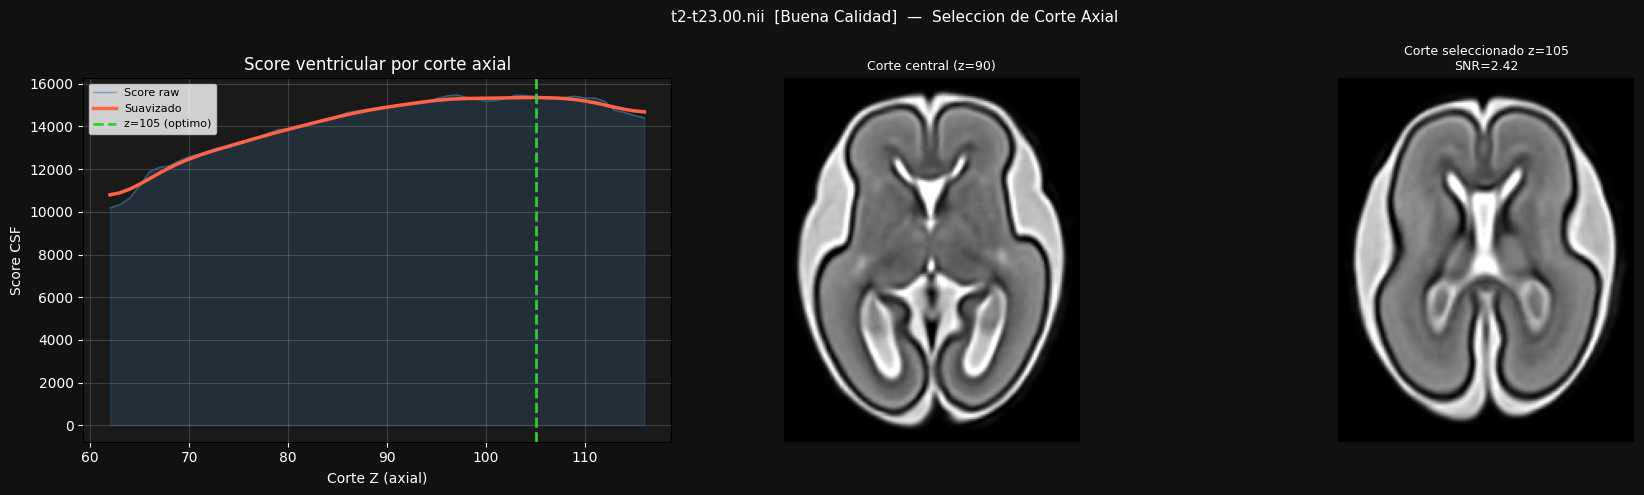

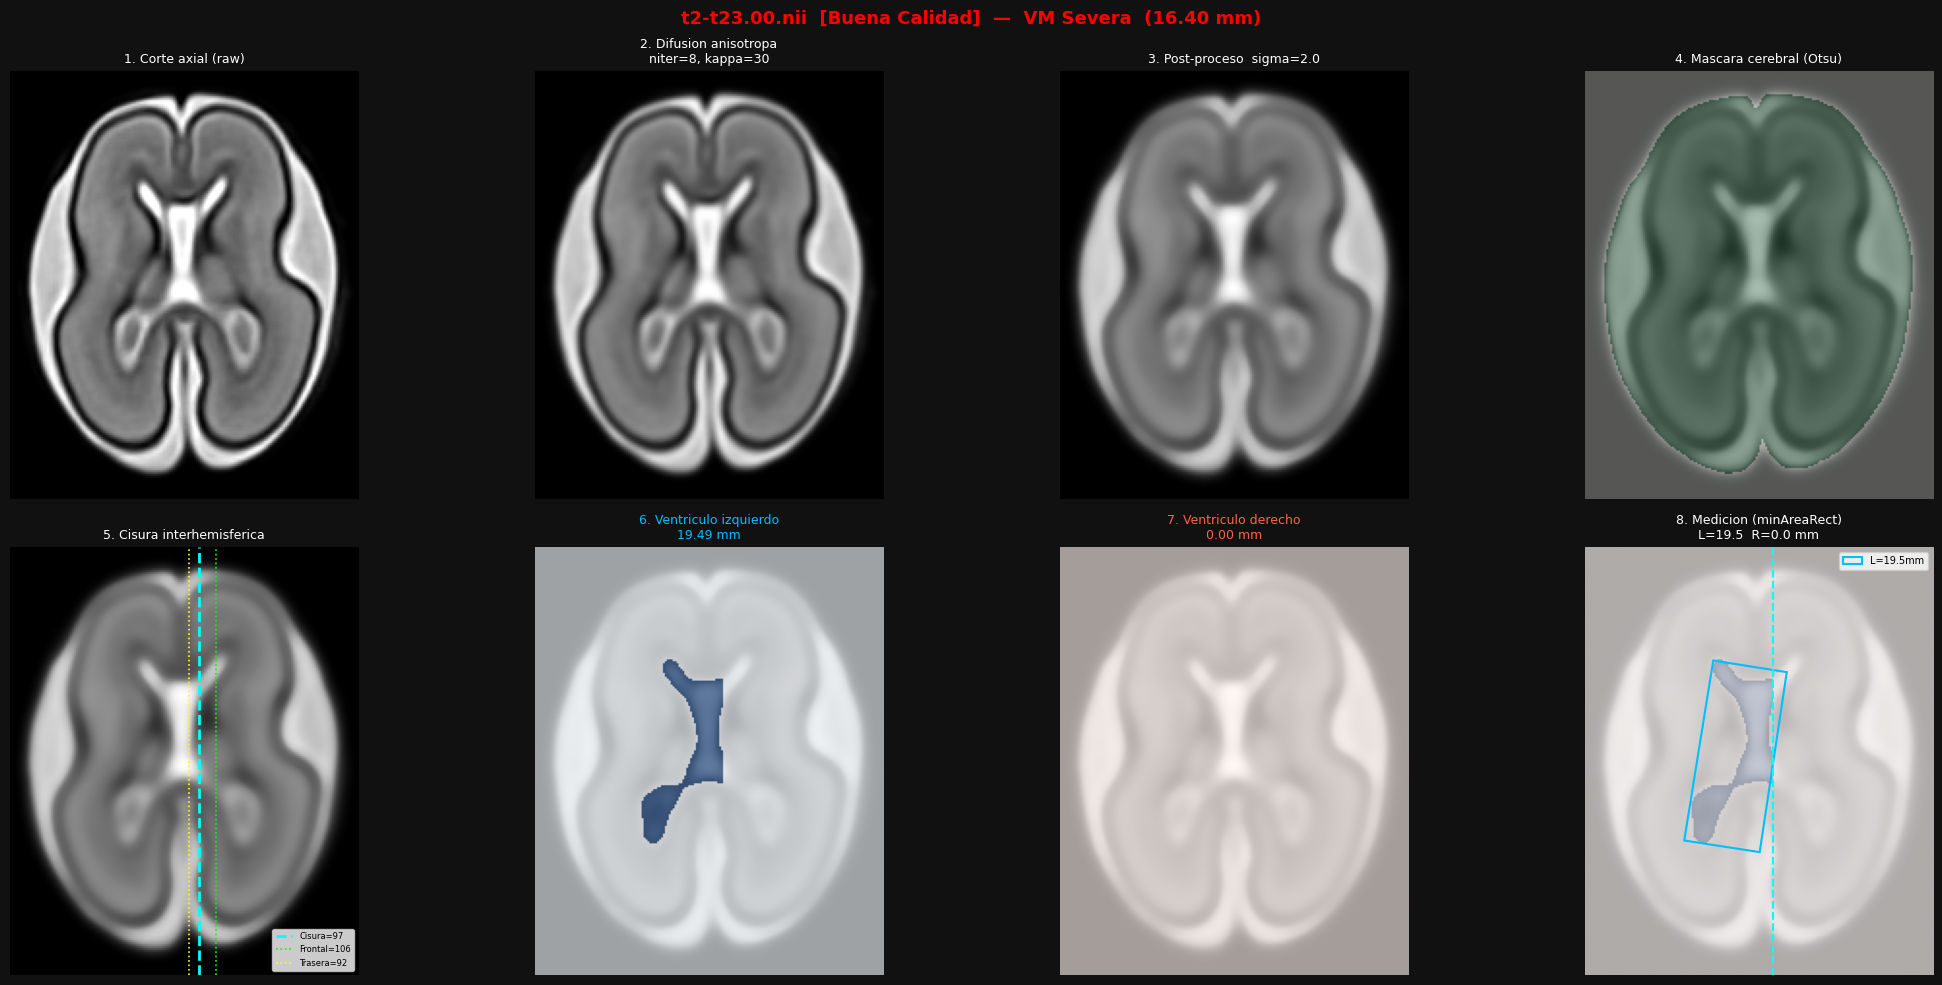

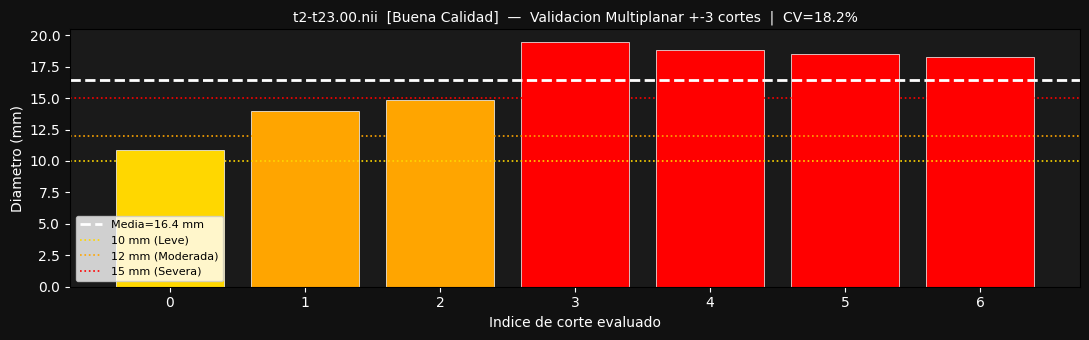


   ── Analisis Digital ─────────────────────────────


,Parametro,Valor
0,Matriz,180 x 221 px
1,Resolucion espacial,0.500 x 0.500 mm/px
2,Bits intensidad,10 bits
3,FOV x,90.0 mm
4,FOV y,110.5 mm
5,Freq. Nyquist x,1.000 c/mm
6,Freq. Nyquist y,1.000 c/mm
7,Media intensidad,165.63
8,Std intensidad,153.23
9,SNR estimado,2.13


In [ ]:
# ==============================================================
# CELDA 9 — ANALISIS: IMAGEN DE BUENA CALIDAD
# ==============================================================
result_good = run_full_pipeline(path_good, 'Buena Calidad', CONFIG)


In [ ]:
# ==============================================================
# CELDA 10 — ANALISIS: IMAGEN DE MALA CALIDAD
# Modo: Mapa LCR brillante central, SIN cisura y SIN division L/R
# ==============================================================

CONFIG.update({
    # Mascara cerebral
    'bad_brain_otsu_factor'       : 0.52,
    'bad_brain_min_size'          : 120,

    # Ventana central
    'bad_center_rx_frac'          : 0.34,
    'bad_center_ry_frac'          : 0.42,
    'bad_boundary_dist_frac'      : 0.085,

    # Mapa LCR brillante
    'bad_prob_core_pct'           : 90,
    'bad_prob_allowed_pct'        : 78,
    'bad_img_support_pct'         : 72,

    # Componentes centrales
    'bad_min_component_px'        : 7,
    'bad_max_component_frac'      : 0.035,
    'bad_max_centrality'          : 0.78,
    'bad_seed_growth_r'           : 10,
    'bad_keep_centered_components': 3,

    # Morfologia
    'bad_close_r'                 : 1,
    'bad_open_r'                  : 1,
})


def _bad_largest_component(mask, min_size=1):
    labeled, n_lab = scipy_label(mask.astype(bool))

    best = np.zeros_like(mask, dtype=bool)
    best_area = 0

    for lab in range(1, n_lab + 1):
        comp = labeled == lab
        area = int(comp.sum())

        if area >= min_size and area > best_area:
            best = comp
            best_area = area

    return best.astype(bool)


def _bad_components(mask, min_size=1):
    labeled, n_lab = scipy_label(mask.astype(bool))
    comps = []

    for lab in range(1, n_lab + 1):
        comp = labeled == lab
        area = int(comp.sum())

        if area >= min_size:
            comps.append(comp.astype(bool))

    return comps


def _bad_dilate(mask, radius=1):
    if radius <= 0:
        return mask.astype(bool)

    k = disk(int(radius)).astype(np.uint8)

    return cv2.dilate(
        mask.astype(np.uint8),
        k,
        iterations=1
    ).astype(bool)


def _bad_extract_manual_slice(data_norm, plane, idx, sx, sy, sz):
    plane = plane.lower()

    if plane == 'axial':
        sl = data_norm[:, :, idx]
        spacing = (sx, sy)

    elif plane == 'coronal':
        sl = data_norm[:, idx, :]
        spacing = (sx, sz)

    elif plane == 'sagittal':
        sl = data_norm[idx, :, :]
        spacing = (sy, sz)

    else:
        raise ValueError("plane_bad debe ser 'axial', 'coronal' o 'sagittal'.")

    return sl.copy(), spacing


def mascara_cerebral_mala_calidad(slice_raw, cfg):
    img = normalize_percentile(slice_raw)

    try:
        vals = img[img > 0.02]
        t = threshold_otsu(vals) if len(vals) > 20 else threshold_otsu(img)
    except Exception:
        t = 0.05

    mask = img > max(0.035, t * cfg['bad_brain_otsu_factor'])

    mask = binary_closing(mask, disk(3))
    mask = binary_fill_holes(mask)
    mask = remove_small_objects(
        mask.astype(bool),
        min_size=cfg['bad_brain_min_size']
    )

    mask = _bad_largest_component(
        mask,
        min_size=cfg['bad_brain_min_size']
    )

    mask = binary_closing(mask, disk(2))
    mask = binary_fill_holes(mask)

    return mask.astype(bool)


def crear_mapa_lcr_brillante_mala_calidad(slice_proc, brain_mask, cfg):
    brain = brain_mask.astype(bool)

    img = normalize_percentile(slice_proc)
    img = gaussian_filter(img, sigma=0.65)

    rr, cc = np.where(brain)

    rmin, rmax = int(rr.min()), int(rr.max())
    cmin, cmax = int(cc.min()), int(cc.max())

    brain_w = max(rmax - rmin + 1, 1)
    brain_h = max(cmax - cmin + 1, 1)

    cx_box = 0.5 * (rmin + rmax)
    cy_box = 0.5 * (cmin + cmax)

    cx_centroid = float(rr.mean())
    cy_centroid = float(cc.mean())

    dist = cv2.distanceTransform(
        brain.astype(np.uint8),
        cv2.DIST_L2,
        3
    )

    max_pos = np.unravel_index(np.argmax(dist), dist.shape)
    cx_dist, cy_dist = float(max_pos[0]), float(max_pos[1])

    centro_x = 0.55 * cx_box + 0.30 * cx_centroid + 0.15 * cx_dist
    centro_y = 0.55 * cy_box + 0.30 * cy_centroid + 0.15 * cy_dist

    R, C = np.indices(img.shape)

    rx = max(8, brain_w * cfg['bad_center_rx_frac'])
    ry = max(8, brain_h * cfg['bad_center_ry_frac'])

    ventana_central = (
        (((R - centro_x) / (rx + 1e-8)) ** 2 +
         ((C - centro_y) / (ry + 1e-8)) ** 2) <= 1.0
    )

    ventana_central &= brain

    min_dist = max(
        3,
        int(min(brain_w, brain_h) * cfg['bad_boundary_dist_frac'])
    )

    interior = brain & (dist >= min_dist)
    zona_busqueda = ventana_central & interior

    if zona_busqueda.sum() < 25:
        zona_busqueda = ventana_central.copy()

    img_u8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)

    ksize = int(max(7, min(25, round(min(brain_w, brain_h) * 0.10))))

    if ksize % 2 == 0:
        ksize += 1

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (ksize, ksize)
    )

    top_hat = cv2.morphologyEx(
        img_u8,
        cv2.MORPH_TOPHAT,
        kernel
    ).astype(np.float64) / 255.0

    top_hat = normalize_percentile(top_hat, 1, 99)

    prob = 0.62 * img + 0.38 * top_hat
    prob = normalize_percentile(prob, 1, 99)
    prob = gaussian_filter(prob, sigma=0.35)

    return {
        'img': img,
        'prob': prob,
        'top_hat': top_hat,
        'brain': brain,
        'interior': interior,
        'ventana_central': ventana_central,
        'zona_busqueda': zona_busqueda,
        'centro_x': centro_x,
        'centro_y': centro_y,
        'rx': rx,
        'ry': ry,
        'dist': dist,
        'min_dist': min_dist,
    }


def segmentar_lcr_central_mala_calidad(slice_proc, brain_mask, cfg, return_debug=False):
    brain = brain_mask.astype(bool)

    if brain.sum() == 0:
        z = np.zeros_like(brain, dtype=bool)

        dbg = {
            'img': z.astype(float),
            'prob': z.astype(float),
            'top_hat': z.astype(float),
            'brain': z,
            'interior': z,
            'ventana_central': z,
            'zona_busqueda': z,
            'lcr_final': z,
            'centro_x': slice_proc.shape[0] / 2,
            'centro_y': slice_proc.shape[1] / 2,
            'rx': 1,
            'ry': 1,
            'dist': z.astype(float),
            'candidatos': [],
            'seleccionados': [],
        }

        return (z, dbg) if return_debug else z

    dbg = crear_mapa_lcr_brillante_mala_calidad(
        slice_proc,
        brain,
        cfg
    )

    img = dbg['img']
    prob = dbg['prob']
    zona_busqueda = dbg['zona_busqueda']
    centro_x = dbg['centro_x']
    centro_y = dbg['centro_y']
    rx = dbg['rx']
    ry = dbg['ry']
    dist = dbg['dist']
    min_dist = dbg['min_dist']

    roi_prob = prob[zona_busqueda]
    roi_img = img[zona_busqueda]

    if len(roi_prob) < 20:
        z = np.zeros_like(brain, dtype=bool)
        dbg['lcr_final'] = z
        dbg['candidatos'] = []
        dbg['seleccionados'] = []
        return (z, dbg) if return_debug else z

    # Mascara principal desde el Mapa LCR brillante.
    core_p = np.percentile(roi_prob, cfg['bad_prob_core_pct'])
    allowed_p = np.percentile(roi_prob, cfg['bad_prob_allowed_pct'])
    img_support = np.percentile(roi_img, cfg['bad_img_support_pct'])

    semillas = (prob >= core_p) & zona_busqueda

    mapa_candidato = (prob >= allowed_p) & zona_busqueda
    mapa_candidato |= (
        (img >= img_support) &
        (prob >= np.percentile(roi_prob, 72)) &
        zona_busqueda
    )

    semillas = binary_closing(semillas, disk(cfg['bad_close_r']))
    semillas = remove_small_objects(
        semillas.astype(bool),
        min_size=cfg['bad_min_component_px']
    )

    mapa_candidato = binary_closing(mapa_candidato, disk(cfg['bad_close_r']))
    mapa_candidato = binary_opening(mapa_candidato, disk(cfg['bad_open_r']))
    mapa_candidato = remove_small_objects(
        mapa_candidato.astype(bool),
        min_size=cfg['bad_min_component_px']
    )

    max_area = int(brain.sum() * cfg['bad_max_component_frac'])
    min_px = int(cfg['bad_min_component_px'])

    seed_comps = _bad_components(semillas, min_size=min_px)

    candidatos = []

    for seed_comp in seed_comps:
        local_roi = _bad_dilate(
            seed_comp,
            radius=cfg['bad_seed_growth_r']
        )

        local_candidate = mapa_candidato & local_roi

        labeled, n_lab = scipy_label(local_candidate.astype(bool))

        grown = np.zeros_like(seed_comp, dtype=bool)

        for lab in range(1, n_lab + 1):
            comp_lab = labeled == lab

            if (comp_lab & seed_comp).any():
                grown |= comp_lab

        if grown.sum() == 0:
            grown = seed_comp.copy()

        grown = binary_closing(grown, disk(1))
        grown = binary_fill_holes(grown)

        if grown.sum() > max_area:
            grown = seed_comp.copy()

        area = int(grown.sum())

        if area < min_px or area > max_area:
            continue

        cr, cc2 = np.where(grown)

        comp_cx = float(cr.mean())
        comp_cy = float(cc2.mean())

        centralidad = np.sqrt(
            ((comp_cx - centro_x) / (rx + 1e-8)) ** 2 +
            ((comp_cy - centro_y) / (ry + 1e-8)) ** 2
        )

        if centralidad > cfg['bad_max_centrality']:
            continue

        dist_med = float(np.median(dist[grown]))
        dist_score = min(1.0, dist_med / (min_dist + 1e-8))

        mean_prob = float(prob[grown].mean())
        max_prob = float(prob[grown].max())

        high_t = np.percentile(roi_prob, 88)
        bright_frac = float(np.mean(prob[grown] >= high_t))

        h = float(cr.max() - cr.min() + 1)
        w = float(cc2.max() - cc2.min() + 1)
        elong = max(h, w) / max(min(h, w), 1.0)

        elong_penalty = 12.0 * max(0, elong - 4.0)

        score = (
            300.0 * mean_prob +
            140.0 * max_prob +
            120.0 * bright_frac +
             80.0 * dist_score +
              8.0 * np.log1p(area) -
            330.0 * centralidad -
             elong_penalty
        )

        info = {
            'area': area,
            'cx': comp_cx,
            'cy': comp_cy,
            'centralidad': centralidad,
            'dist_med': dist_med,
            'mean_prob': mean_prob,
            'max_prob': max_prob,
            'bright_frac': bright_frac,
            'elong': elong,
            'score': score,
        }

        candidatos.append((score, grown.astype(bool), info))

    candidatos.sort(key=lambda x: x[0], reverse=True)

    lcr_final = np.zeros_like(brain, dtype=bool)
    seleccionados = []

    for score, comp, info in candidatos[:cfg['bad_keep_centered_components']]:
        lcr_final |= comp
        seleccionados.append(info)

    if lcr_final.sum() == 0 and seed_comps:
        fallback = []

        for comp in seed_comps:
            cr, cc2 = np.where(comp)

            comp_cx = float(cr.mean())
            comp_cy = float(cc2.mean())

            centralidad = np.sqrt(
                ((comp_cx - centro_x) / (rx + 1e-8)) ** 2 +
                ((comp_cy - centro_y) / (ry + 1e-8)) ** 2
            )

            fallback.append((centralidad, comp))

        fallback.sort(key=lambda x: x[0])

        for _, comp in fallback[:cfg['bad_keep_centered_components']]:
            lcr_final |= comp

    lcr_final = binary_closing(lcr_final, disk(1))
    lcr_final = remove_small_objects(
        lcr_final.astype(bool),
        min_size=cfg['bad_min_component_px']
    )

    if lcr_final.sum() > max_area * 2 and candidatos:
        lcr_final = np.zeros_like(brain, dtype=bool)

        for _, comp, info in candidatos[:2]:
            lcr_final |= comp

    dbg['lcr_final'] = lcr_final.astype(bool)
    dbg['semillas_lcr'] = semillas.astype(bool)
    dbg['mapa_candidato'] = mapa_candidato.astype(bool)
    dbg['candidatos'] = candidatos
    dbg['seleccionados'] = seleccionados

    print('Objetos LCR centrales seleccionados:')

    if not seleccionados:
        print('  Ningun objeto central fuerte. Se uso fallback conservador.')

    for i, info in enumerate(seleccionados, start=1):
        print(
            f"  {i}. area={info['area']} px | "
            f"centralidad={info['centralidad']:.3f} | "
            f"mean_prob={info['mean_prob']:.3f} | "
            f"score={info['score']:.1f}"
        )

    return (lcr_final.astype(bool), dbg) if return_debug else lcr_final.astype(bool)


def medir_objetos_lcr_mala_calidad(lcr_mask, sp_x, sp_y, cfg):
    comps = _bad_components(
        lcr_mask,
        min_size=cfg['bad_min_component_px']
    )

    mediciones = []

    for comp in comps:
        width_mm, rect = min_bounding_rect_width(comp, sp_x, sp_y)

        if width_mm > 0 and rect is not None:
            mediciones.append({
                'mask': comp,
                'width_mm': float(width_mm),
                'rect': rect,
                'area_px': int(comp.sum())
            })

    mediciones.sort(key=lambda x: x['width_mm'], reverse=True)

    if not mediciones:
        return 0.0, None, []

    return mediciones[0]['width_mm'], mediciones[0]['rect'], mediciones


def visualizar_mala_calidad_central(result, dbg, cfg):
    slice_raw = result['_slice_raw']
    slice_aniso = result['_slice_aniso']
    slice_proc = result['_slice_proc']
    brain_mask = result['_brain_mask']
    lcr_mask = result['_lcr_mask']

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    fig.patch.set_facecolor('#111111')

    fig.suptitle(
        f"{result['fname']}  [Mala Calidad] — Mapa LCR brillante central "
        f"({result['final_diameter']:.2f} mm, {result['classification']})",
        color=result['class_color'],
        fontsize=13,
        fontweight='bold'
    )

    for ax in axes.flatten():
        ax.set_facecolor('#1a1a1a')
        ax.axis('off')

    kw = dict(origin='lower')

    axes[0, 0].imshow(slice_raw.T, cmap='gray', **kw)
    axes[0, 0].set_title('1. Corte manual raw', color='white', fontsize=9)

    axes[0, 1].imshow(slice_aniso.T, cmap='gray', **kw)
    axes[0, 1].set_title('2. Difusion anisotropa', color='white', fontsize=9)

    axes[0, 2].imshow(slice_proc.T, cmap='gray', **kw)
    axes[0, 2].set_title(f"3. Post-proceso sigma={result['sigma']}", color='white', fontsize=9)

    axes[0, 3].imshow(slice_proc.T, cmap='gray', **kw)
    axes[0, 3].imshow(brain_mask.T, cmap='Greens', alpha=0.35, **kw)
    axes[0, 3].set_title('4. Mascara cerebral robusta', color='white', fontsize=9)

    axes[1, 0].imshow(slice_proc.T, cmap='gray', **kw)
    axes[1, 0].imshow(dbg['zona_busqueda'].T, cmap='Greens', alpha=0.35, **kw)
    axes[1, 0].scatter(
        [dbg['centro_x']],
        [dbg['centro_y']],
        c='cyan',
        s=35,
        marker='+'
    )
    axes[1, 0].set_title('5. Zona central sin periferia', color='white', fontsize=9)

    axes[1, 1].imshow(dbg['prob'].T, cmap='magma', **kw)
    axes[1, 1].set_title('6. Mapa LCR brillante', color='white', fontsize=9)

    axes[1, 2].imshow(slice_proc.T, cmap='gray', **kw)
    axes[1, 2].imshow(lcr_mask.T, cmap='cool', alpha=0.70, **kw)
    axes[1, 2].set_title('7. Objetos LCR centrales seleccionados', color='white', fontsize=9)

    axes[1, 3].imshow(slice_proc.T, cmap='gray', **kw)
    axes[1, 3].imshow(lcr_mask.T, cmap='cool', alpha=0.55, **kw)

    for i, med in enumerate(result['_lcr_measurements'], start=1):
        draw_rect_on_ax(
            axes[1, 3],
            med['rect'],
            'cyan',
            f"Obj {i}={med['width_mm']:.1f} mm"
        )

    axes[1, 3].set_title(
        f"8. Medicion objetos centrales\n"
        f"Diametro final={result['final_diameter']:.1f} mm",
        color='white',
        fontsize=9
    )

    try:
        axes[1, 3].legend(fontsize=7)
    except Exception:
        pass

    plt.tight_layout()
    plt.show()


def run_bad_quality_center_csf(path, quality_label, cfg, plane_bad='axial', slice_bad=67):
    print('\n' + '=' * 62)
    print(f'  ANALIZANDO : {Path(path).name}')
    print(f'  Calidad    : {quality_label}')
    print(f'  Modo       : MALA CALIDAD — Mapa LCR brillante central')
    print(f'  Plano/corte: {plane_bad} / {slice_bad}')
    print('=' * 62)

    img = nib.load(path)
    img = nib.as_closest_canonical(img)

    data_raw = img.get_fdata().squeeze().astype(np.float32)

    zooms = img.header.get_zooms()
    sx = float(zooms[0])
    sy = float(zooms[1])
    sz = float(zooms[2])

    data_norm = normalize_percentile(
        data_raw,
        cfg['pct_low'],
        cfg['pct_high']
    )

    slice_full, (sp_x, sp_y) = _bad_extract_manual_slice(
        data_norm,
        plane_bad,
        slice_bad,
        sx,
        sy,
        sz
    )

    r0, r1, c0, c1 = get_roi_from_slice(
        slice_full,
        cfg['brain_thresh'],
        cfg['roi_margin']
    )

    slice_raw = slice_full[r0:r1, c0:c1].copy()

    slice_aniso = anisotropic_diffusion(
        slice_raw,
        niter=cfg['aniso_niter'],
        kappa=cfg['aniso_kappa'],
        gamma=cfg['aniso_gamma']
    )

    slice_proc, snr_val, sigma_used = preprocess_slice(slice_aniso, cfg)

    brain_mask = mascara_cerebral_mala_calidad(slice_raw, cfg)

    lcr_mask, dbg = segmentar_lcr_central_mala_calidad(
        slice_proc,
        brain_mask,
        cfg,
        return_debug=True
    )

    width_single, rect_final, measurements = medir_objetos_lcr_mala_calidad(
        lcr_mask,
        sp_x,
        sp_y,
        cfg
    )

    widths_mp = []
    n_cross = int(cfg['cross_slices'])

    for d in range(-n_cross, n_cross + 1):
        idx = int(slice_bad + d)

        try:
            slice_full_i, _ = _bad_extract_manual_slice(
                data_norm,
                plane_bad,
                idx,
                sx,
                sy,
                sz
            )

            rr0, rr1, cc0, cc1 = get_roi_from_slice(
                slice_full_i,
                cfg['brain_thresh'],
                cfg['roi_margin']
            )

            sl_i = slice_full_i[rr0:rr1, cc0:cc1].copy()

            sl_a = anisotropic_diffusion(
                sl_i,
                niter=cfg['aniso_niter'],
                kappa=cfg['aniso_kappa'],
                gamma=cfg['aniso_gamma']
            )

            sl_p, _, _ = preprocess_slice(sl_a, cfg)
            bm_i = mascara_cerebral_mala_calidad(sl_i, cfg)

            lcr_i, _ = segmentar_lcr_central_mala_calidad(
                sl_p,
                bm_i,
                cfg,
                return_debug=True
            )

            w_i, _, _ = medir_objetos_lcr_mala_calidad(
                lcr_i,
                sp_x,
                sp_y,
                cfg
            )

            if w_i > 0:
                widths_mp.append(float(w_i))

        except Exception:
            continue

    if widths_mp:
        mean_w = float(np.mean(widths_mp))
        cv = float(np.std(widths_mp) / (mean_w + 1e-8))
        is_consistent = cv < cfg['cv_thresh']
    else:
        mean_w = width_single
        cv = 0.0
        is_consistent = True

    final_diameter = mean_w if is_consistent else width_single
    diam_source = 'multiplanar central' if is_consistent else 'corte unico central'

    classification, class_color = diagnose(final_diameter, cfg)

    print(f'   Shape      : {data_raw.shape}')
    print(f'   Spacing    : {sx:.3f} x {sy:.3f} x {sz:.3f} mm/px')
    print(f'   ROI        : r=[{r0}:{r1}]  c=[{c0}:{c1}]')
    print(f'   SNR        : {snr_val:.2f}  sigma={sigma_used}')
    print(f'   LCR pixeles: {int(lcr_mask.sum())} px')
    print(f'   Diametro   : {final_diameter:.2f} mm [{diam_source}]')
    print(f'   CV         : {cv * 100:.1f}%')
    print(f'   Clase      : {classification}')

    if plane_bad.lower() == 'axial':
        raw_for_metrics = data_raw[r0:r1, c0:c1, slice_bad]
    elif plane_bad.lower() == 'coronal':
        raw_for_metrics = data_raw[r0:r1, slice_bad, c0:c1]
    else:
        raw_for_metrics = data_raw[slice_bad, r0:r1, c0:c1]

    metrics = digital_analysis_metrics(raw_for_metrics, sp_x, sp_y)

    empty_mask = np.zeros_like(lcr_mask, dtype=bool)

    result = {
        'path': path,
        'quality': quality_label,
        'fname': Path(path).name,
        'plane': plane_bad,
        'z_best': slice_bad,
        'snr': round(snr_val, 2),
        'sigma': sigma_used,

        # Compatibilidad con funciones previas.
        # Aqui NO representa cisura; representa centro cerebral.
        'midline': int(round(dbg['centro_x'])),

        # Compatibilidad con reporte previo.
        # En mala calidad NO hay division izquierda/derecha.
        'width_L_mm': round(final_diameter, 2),
        'width_R_mm': 0.0,
        'dominant_side': 'No dividido',

        'final_diameter': round(final_diameter, 2),
        'diam_source': diam_source,
        'cv_pct': round(cv * 100, 1),
        'consistent': is_consistent,
        'classification': classification,
        'class_color': class_color,
        'metrics': metrics,

        '_slice_raw': slice_raw,
        '_slice_aniso': slice_aniso,
        '_slice_proc': slice_proc,
        '_brain_mask': brain_mask,

        # Nuevas salidas correctas para mala calidad
        '_lcr_mask': lcr_mask,
        '_lcr_measurements': measurements,
        '_rect_final': rect_final,
        '_bad_debug': dbg,

        # Compatibilidad con funciones antiguas
        '_left_v': lcr_mask,
        '_right_v': empty_mask,
        '_rect_L': rect_final,
        '_rect_R': None,
        '_widths_mp': widths_mp,
    }

    visualizar_mala_calidad_central(result, dbg, cfg)

    print('\n   ── Analisis Digital ─────────────────────────────')
    display(pd.DataFrame(metrics.items(), columns=['Parametro', 'Valor']))

    return result


try:
    img_bad_meta = nib.load(path_bad)
    img_bad_meta = nib.as_closest_canonical(img_bad_meta)
    print_metadata_report(path_bad, img_bad_meta, 'Mala Calidad')
except Exception as e:
    print(f'⚠️ No se pudo imprimir reporte de metadatos: {e}')

print('✅ Celda 10 cargada. Ejecuta la Celda 11 para correr mala calidad.')


  METADATOS — Mala Calidad
  Archivo : recon (3).nii
  Shape        : (146, 132, 147)
  Spacing      : 0.750 x 0.750 x 0.750  mm/px
  Orientacion  : ('R', 'A', 'S')
  Rango int.   : [-1.0,  1638.5]
  Dtype        : float64

  (No se encontraron metadatos adicionales de edad fetal)

✅ Celda 10 cargada. Ejecuta la Celda 11 para correr mala calidad.



  ANALIZANDO : recon (3).nii
  Calidad    : Mala Calidad
  Modo       : MALA CALIDAD — Mapa LCR brillante central
  Plano/corte: coronal / 73
Objetos LCR centrales seleccionados:
  1. area=175 px | centralidad=0.073 | mean_prob=0.719 | score=535.7
  2. area=404 px | centralidad=0.278 | mean_prob=0.732 | score=476.6
  3. area=217 px | centralidad=0.307 | mean_prob=0.686 | score=431.1
Objetos LCR centrales seleccionados:
  1. area=374 px | centralidad=0.226 | mean_prob=0.710 | score=478.0
  2. area=53 px | centralidad=0.298 | mean_prob=0.624 | score=367.1
  3. area=408 px | centralidad=0.673 | mean_prob=0.693 | score=314.5
Objetos LCR centrales seleccionados:
  1. area=113 px | centralidad=0.081 | mean_prob=0.725 | score=523.9
  2. area=423 px | centralidad=0.228 | mean_prob=0.756 | score=502.7
  3. area=272 px | centralidad=0.760 | mean_prob=0.725 | score=316.9
Objetos LCR centrales seleccionados:
  1. area=169 px | centralidad=0.086 | mean_prob=0.708 | score=524.7
  2. area=406 px | c

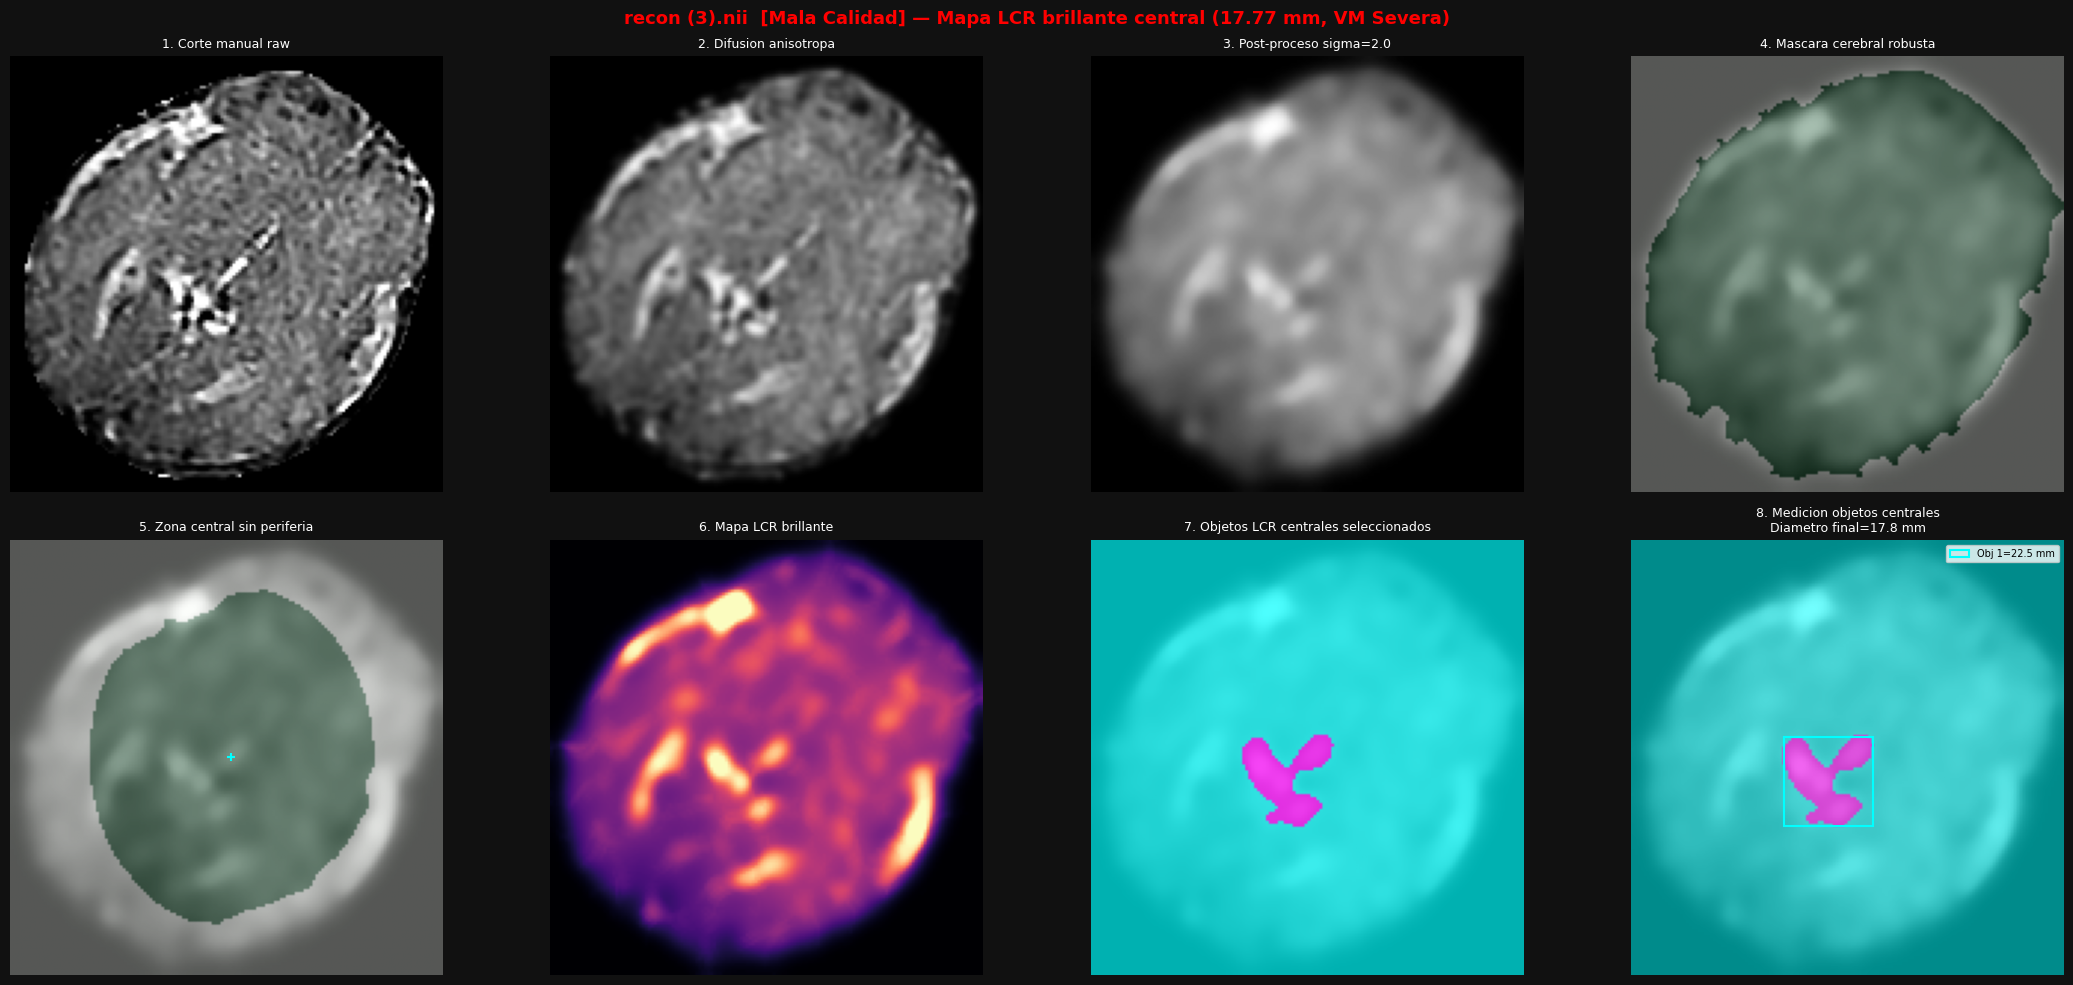


   ── Analisis Digital ─────────────────────────────


,Parametro,Valor
0,Matriz,146 x 147 px
1,Resolucion espacial,0.750 x 0.750 mm/px
2,Bits intensidad,11 bits
3,FOV x,109.5 mm
4,FOV y,110.2 mm
5,Freq. Nyquist x,0.667 c/mm
6,Freq. Nyquist y,0.667 c/mm
7,Media intensidad,256.24
8,Std intensidad,235.54
9,SNR estimado,2.21


In [ ]:
# ==============================================================
# CELDA 11 — EJECUTAR ANALISIS DE MALA CALIDAD
# ==============================================================

result_bad = run_bad_quality_center_csf(
    path_bad,
    'Mala Calidad',
    CONFIG,
    plane_bad=plane_bad,
    slice_bad=slice_bad
)


  REPORTE FINAL — DIAGNOSTICO VENTRICULOMEGALIA FETAL
  Tecnologico de Monterrey · Ingenieria Biomedica · Equipo 4

  Criterio: Normal <10mm | Leve 10-12mm | Moderada 12-15mm | Severa >15mm
  Ref: Pilu et al. 1999; Gaglioti et al. 2005



,Calidad,Archivo,Corte Z,SNR,Cisura (col),Ancho L (mm),Ancho R (mm),Lado dominante,Diametro (mm),Fuente,CV (%),Consistente,Clasificacion
0,Buena Calidad,t2-t23.00.nii,105,2.42,97,19.49,0.0,Izquierdo,16.40,multiplanar,18.2,Si,VM Severa
1,Mala Calidad,recon (3).nii,73,2.77,74,17.77,0.0,No dividido,17.77,multiplanar central,21.3,Si,VM Severa


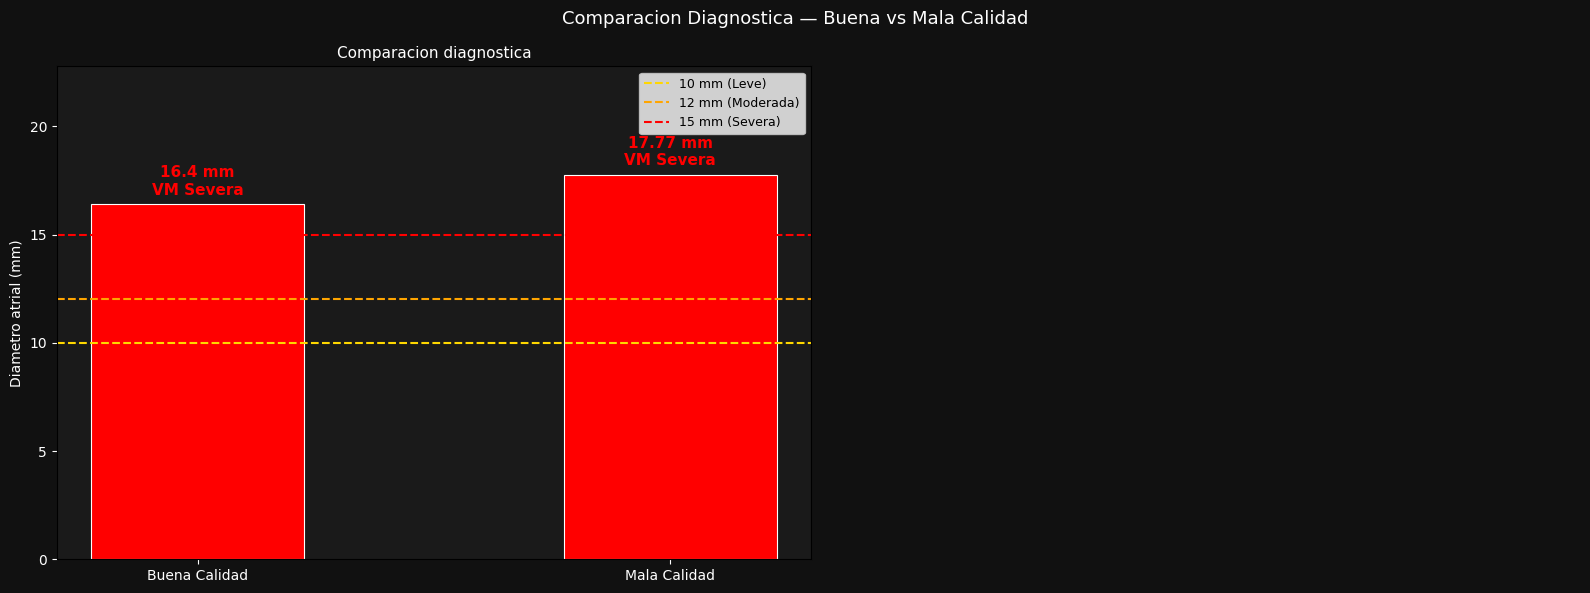

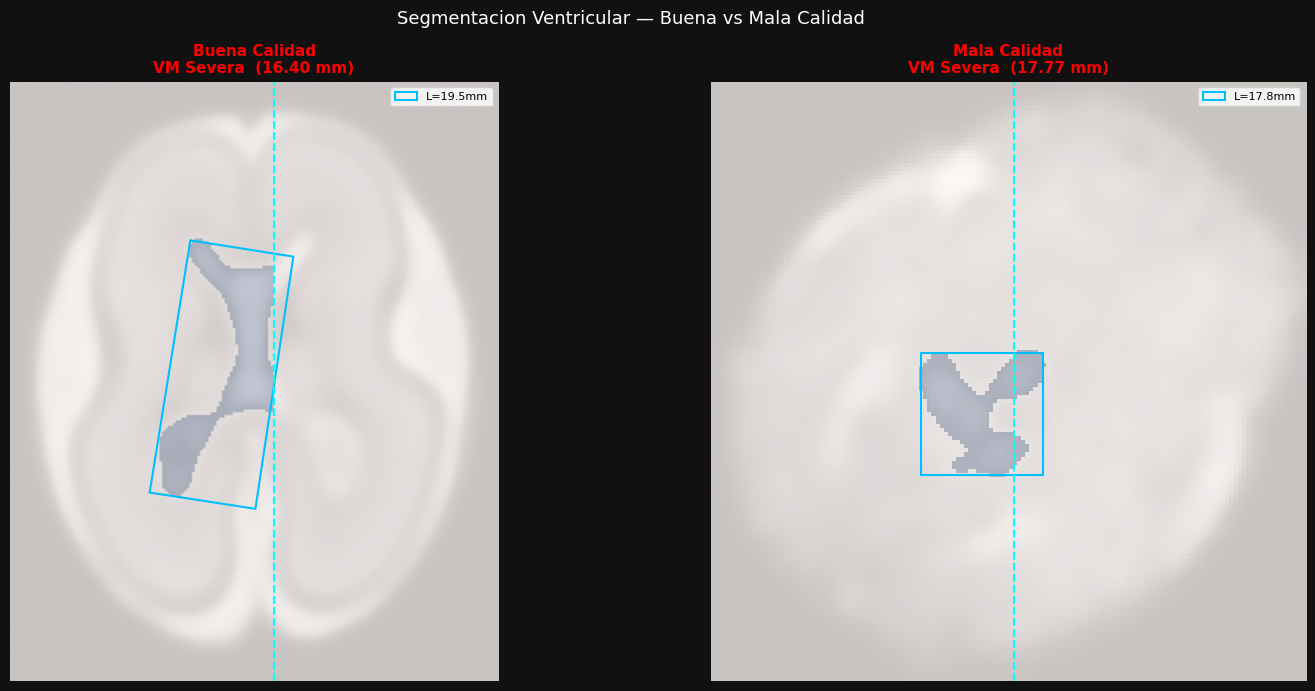


💾  CSV guardado: E:\Benjamin Folder\TecMty\Procesamiento Imagenes medicas\Reto\diagnostico_comparativo.csv

  Analisis completado exitosamente.


In [ ]:
# ==============================================================
# CELDA 11 — REPORTE COMPARATIVO FINAL
# ==============================================================
sep = '=' * 65
print(f'\n{sep}')
print(f'  REPORTE FINAL — DIAGNOSTICO VENTRICULOMEGALIA FETAL')
print(f'  Tecnologico de Monterrey · Ingenieria Biomedica · Equipo 4')
print(f'{sep}')
print(f'\n  Criterio: Normal <10mm | Leve 10-12mm | Moderada 12-15mm | Severa >15mm')
print(f'  Ref: Pilu et al. 1999; Gaglioti et al. 2005')

# ── Tabla comparativa ─────────────────────────────────────────
rows_comp = []
for r in [result_good, result_bad]:
    rows_comp.append({
        'Calidad'        : r['quality'],
        'Archivo'        : r['fname'],
        'Corte Z'        : r['z_best'],
        'SNR'            : r['snr'],
        'Cisura (col)'   : r['midline'],
        'Ancho L (mm)'   : r['width_L_mm'],
        'Ancho R (mm)'   : r['width_R_mm'],
        'Lado dominante' : r['dominant_side'],
        'Diametro (mm)'  : r['final_diameter'],
        'Fuente'         : r['diam_source'],
        'CV (%)'         : r['cv_pct'],
        'Consistente'    : 'Si' if r['consistent'] else 'Revisar',
        'Clasificacion'  : r['classification'],
    })

df_comp = pd.DataFrame(rows_comp)
print()
display(df_comp)

# ── Grafica comparativa de barras ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#111111')

labels = [r['quality']        for r in [result_good, result_bad]]
vals   = [r['final_diameter'] for r in [result_good, result_bad]]
colors = [r['class_color']    for r in [result_good, result_bad]]

ax0 = axes[0]
ax0.set_facecolor('#1a1a1a')
bars = ax0.bar(labels, vals, color=colors, width=0.45, edgecolor='white', lw=0.8)
for bar, r in zip(bars, [result_good, result_bad]):
    ax0.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{r["final_diameter"]} mm\n{r["classification"]}',
             ha='center', va='bottom', fontsize=11,
             fontweight='bold', color=r['class_color'])
ax0.axhline(CONFIG['mild_mm'],     color='gold',   lw=1.5, ls='--', label='10 mm (Leve)')
ax0.axhline(CONFIG['moderate_mm'], color='orange', lw=1.5, ls='--', label='12 mm (Moderada)')
ax0.axhline(CONFIG['severe_mm'],   color='red',    lw=1.5, ls='--', label='15 mm (Severa)')
ax0.set_ylabel('Diametro atrial (mm)', color='white')
ax0.set_title('Comparacion diagnostica', color='white', fontsize=11)
ax0.tick_params(colors='white')
ax0.legend(fontsize=9)
top_val = max(vals) if vals else 20
ax0.set_ylim(0, top_val + 5)

axes[1].axis('off')
axes[1].set_facecolor('#111111')
plt.suptitle('Comparacion Diagnostica — Buena vs Mala Calidad',
             fontsize=13, color='white')
plt.tight_layout()
plt.show()

# ── Panel segmentacion lado a lado ────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 7))
fig2.patch.set_facecolor('#111111')
for ax, r in zip(axes2, [result_good, result_bad]):
    ax.set_facecolor('#1a1a1a')
    ax.imshow(r['_slice_proc'].T, cmap='gray',  origin='lower')
    ax.imshow(r['_left_v'].T,     cmap='Blues', alpha=0.55, origin='lower')
    ax.imshow(r['_right_v'].T,    cmap='Reds',  alpha=0.55, origin='lower')
    ax.axvline(r['midline'], color='cyan', lw=1.5, ls='--')
    draw_rect_on_ax(ax, r['_rect_L'], 'deepskyblue', f'L={r["width_L_mm"]:.1f}mm')
    draw_rect_on_ax(ax, r['_rect_R'], 'tomato',      f'R={r["width_R_mm"]:.1f}mm')
    ax.set_title(f'{r["quality"]}\n{r["classification"]}  ({r["final_diameter"]:.2f} mm)',
                 fontsize=11, fontweight='bold', color=r['class_color'])
    ax.legend(fontsize=8)
    ax.axis('off')

plt.suptitle('Segmentacion Ventricular — Buena vs Mala Calidad',
             fontsize=13, color='white')
plt.tight_layout()
plt.show()

# ── Guardar CSV ───────────────────────────────────────────────
try:
    csv_path = str(Path(path_good).parent / 'diagnostico_comparativo.csv')
    df_comp.to_csv(csv_path, index=False, encoding='utf-8')
    print(f'\n💾  CSV guardado: {csv_path}')
except Exception as e:
    print(f'\n⚠️  No se pudo guardar CSV: {e}')

print(f'\n{sep}')
print(f'  Analisis completado exitosamente.')
print(f'{sep}')
